# Market Sentiment Predictor

Geovanni Jones, Josh Previte, Casey Barrasso

The goal of this project is to predict the directional price movement of a specific stock using both historical price data and news information. Two separate models will predict price movements based on historical data and analyze news sentiment.

In [1]:
# This is used to generate the requirements.txt file for the project.
#!pip freeze > requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
import torch
import gc
import joblib


#from pandas.errors import SettingWithCopyWarning

from collections import Counter

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

#!pip install imblearn
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression as LR
from sklearn.svm import SVC
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.utils import resample

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score

from scipy.sparse import hstack, csr_matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report as CR
#from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, f1_score

#install transformers if not already done
#!pip install transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import warnings
warnings.filterwarnings("ignore")

!pip install shap
import shap


Defaulting to user installation because normal site-packages is not writeable


# Data Ingestion

There are two main datasets to this project. The first is a dataset containing news article content including titles, content, and sentiment scores from various news sources around the AAPL stock. The second dataset (introduced later in the notebook) contains a time series of AAPL stock prices. The final dataset will combine the two datasets on date.

We are trying to predict the directional movement of AAPL stock between periods. Therefore, our target variable will be a binary indicator that represents the directional change in closing price between consecutive trading periods. The returns are calculated as a percentage in difference between opening and closing price for the day. A positive directional movement would indicate an increase of closing price at time t+1 relative to time t.The labels will be defined as 1 for an increase and 0 for a decrease or no change.

The primary predictor variable in this study is the news sentiment score derived from articles related to AAPL. For each time period, news articles are aggregated to produce a sentiment polarity score ranging from −0.99 to 1.00, where negative values indicate negative sentiment, positive values indicate positive sentiment, and values near zero indicate neutral sentiment. In addition, we will also use the percent of positive, neutral, and negative language within the text. This is different than the overall polarity score since it focuses on individual words instead of the overall sentiment of the document. We will also use lagged stock prices as additional predictor variables. The lag in days ranges from one to five, as the model will have more information about recent stock activity and patterns may arise beyond day-to-day.

## Sentiment Dataset

In [3]:
#Github didn't allow us to upload a file more than 25MB. This is combining all files into one file
def sentiment_data_creation():
    raw_data_1 = pd.read_csv('../data/apple_news_data_1.csv', encoding='latin-1')
    raw_data_2 = pd.read_csv('../data/apple_news_data_2.csv', encoding='latin-1')
    raw_data_3 = pd.read_csv('../data/apple_news_data_3.csv', encoding='latin-1')
    raw_data_4 = pd.read_csv('../data/apple_news_data_4.csv', encoding='latin-1')
    raw_data_5 = pd.read_csv('../data/apple_news_data_5.csv', encoding='latin-1')

    raw_data = pd.concat([raw_data_1, raw_data_2, raw_data_3, raw_data_4, raw_data_5])[['date', 'title', 'content', 'link', 'symbols', 'tags', 'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos']]
    return raw_data

raw_data = sentiment_data_creation()

In [4]:
# Sort raw_data by date column from earliest to latest
raw_data = raw_data.sort_values('date', ascending=True).reset_index(drop=True)

In [5]:
#Drop Clumns we won't be focusing on (link and tags)
raw_data = raw_data.drop(columns=['link', 'tags'])

In [6]:
# force sentiment scores to be a numerical value, NA if not 
for col in ['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# extract valid calendar dates only (ignore time + BST noise)
raw_data['date'] = pd.to_datetime(
    raw_data['date'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
    errors='coerce'
) #This section of the code was inputed to handle warnings from pandas that could lead to future breakage of the code.

# convert content to string
raw_data['content'] = raw_data['content'].astype('str')

#this data is messy, drop observations that have NAs in critical columns
raw_data = raw_data.dropna(subset=['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity','content','date'])

#print out the data type of each column to ensure conversions from above worked
for col in raw_data.columns:
    print(f'Column: {col} , Data Type: {raw_data[col].dtype}')


Column: date , Data Type: datetime64[ns]
Column: title , Data Type: object
Column: content , Data Type: object
Column: symbols , Data Type: object
Column: sentiment_polarity , Data Type: float64
Column: sentiment_neg , Data Type: float64
Column: sentiment_neu , Data Type: float64
Column: sentiment_pos , Data Type: float64


In [7]:
# Dropping rows before January 1, 2018 and after October 31, 2024
raw_data = raw_data[(raw_data['date'] >= '2018-01-01') & (raw_data['date'] <= '2024-10-31')]

print(raw_data.shape)

#Data range for raw_data
print(f"Date range for raw_data: {raw_data['date'].min()} to {raw_data['date'].max()}")

(29635, 8)
Date range for raw_data: 2018-01-31 00:00:00 to 2024-10-31 00:00:00


No news sentiment data was available prior to January 2018, which is why all data before this point was dropped. This dataset has 29,635 rows and 9 columns (plus the net sentiment score column created by us)

## Price Timeseries Dataset

In [8]:
ts_data = pd.read_csv('../data/AAPL Stock Data.csv')

In [9]:
#Convert values to the expected formatting
ts_data['Dates'] = pd.to_datetime(ts_data['Dates']).dt.date
ts_data['AAPL Share Price'] = ts_data['AAPL Share Price'].astype('float')

In [10]:
for col in ts_data.columns:
    print(f'Column: {col} , Data Type: {type(ts_data[col][0])}')

Column: Dates , Data Type: <class 'datetime.date'>
Column: AAPL Share Price , Data Type: <class 'numpy.float64'>


In [11]:
# Setting "Dates" column to datetime format
ts_data['Dates'] = pd.to_datetime(ts_data['Dates'])

# Dropping rows before January 1, 2018 and after October 31, 2024
ts_data = ts_data[(ts_data['Dates'] >= '2018-01-01') & (ts_data['Dates'] <= '2024-10-31')]

print(ts_data.shape)
print(f"Date range: {ts_data['Dates'].min()} to {ts_data['Dates'].max()}")

(1720, 2)
Date range: 2018-01-02 00:00:00 to 2024-10-31 00:00:00


There are 1,720 rows in this dataset and two columns (date and price).

# Training/Validation/Test Data Split

The strategy of data partitioning between training, validation, and test datasets was to follow the 60/20/20 rule advised in academic articles (Muraina), as well as other courses of the Applied Analytics program. This rule states that generally, 60% of the entire dataset should be used for training, 20% for model validation, and 20% as a test dataset. This allows the majority of the dataset to be devoted to model training, a sizable portion to evaluate possible models, and another sizable portion to act as a never-before-seen dataset.

A chronological split of the dataset is ideal for this project since it prevents data leakage and look-ahead bias. With this split, future information cannot improve past predictions.

The training section of the sentiment dataset encompassed January 2018 through October 2022, resulting in 15,474 rows. The validation set covered November 2022 through October 2023 (7,598 rows) and the test dataset covered November 2023 through October 2024 (6,563 rows). Not every date contained a news article about the AAPL stock, and some dates also contained duplicates, hence the differing number of observations over time periods of the same length.

The AAPL stock price dataset was also partitioned using the same date cutoffs. The resulting datasets had 1,217 rows (training), 251 rows (validation) and 252 rows (test). The sentiment datasets were then aggregated so that each row contained one day and the average sentiment polarity in news articles for that day. These dataset was joined on the stock price datasets to achieve cohesive training, validation, and test datasets.    



## Split Sentiment Dataset

In [12]:
raw_data = raw_data.sort_values("date").reset_index(drop=True)

raw_train = raw_data[(raw_data["date"] >= "2018-01-01") & (raw_data["date"] <= "2022-10-31")]
raw_val   = raw_data[(raw_data["date"] >= "2022-11-01") & (raw_data["date"] <= "2023-10-31")]
raw_test  = raw_data[(raw_data["date"] >= "2023-11-01") & (raw_data["date"] <= "2024-10-31")]

## Split Price Dataset

In [13]:
ts_data = ts_data.sort_values("Dates").reset_index(drop=True)

ts_train = ts_data[(ts_data["Dates"] >= "2018-01-01") & (ts_data["Dates"] <= "2022-10-31")]
ts_val   = ts_data[(ts_data["Dates"] >= "2022-11-01") & (ts_data["Dates"] <= "2023-10-31")]
ts_test  = ts_data[(ts_data["Dates"] >= "2023-11-01") & (ts_data["Dates"] <= "2024-10-31")]

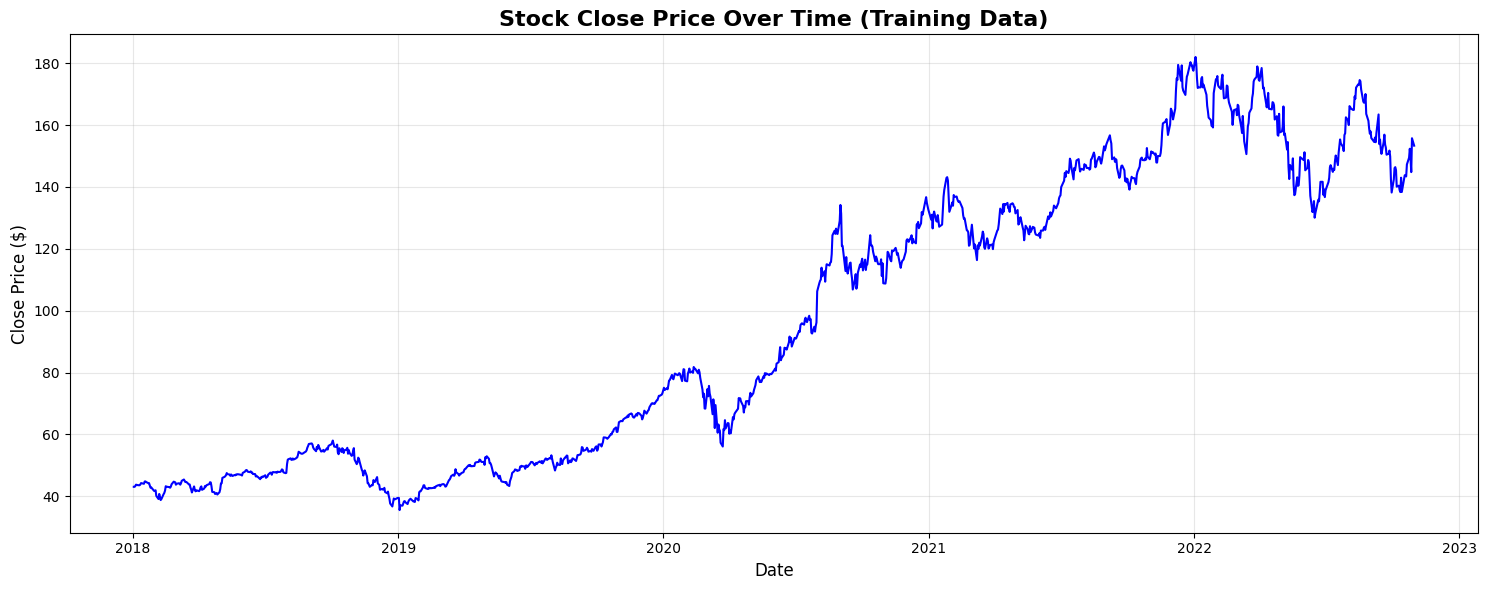

In [14]:
# Time Series Plot of Close Price
plt.figure(figsize=(15, 6))
plt.plot(ts_train['Dates'], ts_train['AAPL Share Price'], linewidth=1.5, color='blue')
plt.title('Stock Close Price Over Time (Training Data)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

During the period of time covered by the train data, AAPL stock fluctuates, but increases overall from July, 2020 to about January 2022. Then, it continues to fluctuate but trends down until July, 2022. It's important to note here that the training data contains majority of observations with an increase in stock price, while the validation and test datasets are much more mixed. Future data manipulations will need to ensure that a model is trained with an even target variable class distribution.

# Data Preparation

## Sentiment Dataset Cleaning

In order to make the sentiment dataset ready for modeling we will first combine our title and content columns into one full text column. We will aggregate full_text column by date to create a daily text feature for modeling and aggregate sentiment_polarity, sentiment_neg, sentiment_neu and sentiment_pos by mean for each date. This will create a daily summary of the news articles and their sentiment scores.

Combine each dataset (train, validation and test) with the corresponding dates in timeseries dataset (ts_train, ts_val, ts_test) to create the final training datasets that contains the daily aggregated full_text, sentiment_neg, sentiment_neu, and sentiment_pos along with the AAPL Share Price for each date. We use time series dates as the main column dates so that all sentiment datasets dates are aligned with ts_train dates. This will allow us to have a complete dataset for modeling that includes both the text features and the target variable.

Finally we will fill missing data in the full_text column by replacing NaN values with a blank string to avoid putting in placeholders that would otherwise introduce noice into the model. We will forward fill sentiment values up to 7 days as news diminishes overtime and will leave the remaining values at 0.

### Data Pre-Processing

In [15]:
#Combine title and content into a single text column for NLP processing and consistency across train, val, and test sets. 
raw_train['full_text'] = raw_train['title'] + ' ' + raw_train['content']
raw_val['full_text'] = raw_val['title'] + ' ' + raw_val['content']
raw_test['full_text'] = raw_test['title'] + ' ' + raw_test['content']

In [16]:
# Remove unnecessary columns from train, val, and test sets to focus on text and sentiment features.
raw_train = raw_train.drop(columns=['title', 'content'])
raw_val = raw_val.drop(columns=['title', 'content'])
raw_test = raw_test.drop(columns=['title', 'content'])

In [17]:
# Aggregate columns by date to create a daily text feature for modeling
# Aggregate sentiment columns by mean for each date.
raw_train = raw_train.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),  # Combine all text for the day
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
})

raw_val = raw_val.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),  # Combine all text for the day
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
})

raw_test = raw_test.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),  # Combine all text for the day
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
})

### NLP Pre-Processing

In [18]:
# lowercase the text for consistency in NLP processing
raw_train['full_text'] = raw_train['full_text'].str.lower()
raw_val['full_text'] = raw_val['full_text'].str.lower()
raw_test['full_text'] = raw_test['full_text'].str.lower()

In [19]:
# Remove punctuation and special characters from the text
raw_train['full_text'] = raw_train['full_text'].str.replace(r'[^\w\s]', '', regex=True)
raw_val['full_text'] = raw_val['full_text'].str.replace(r'[^\w\s]', '', regex=True)
raw_test['full_text'] = raw_test['full_text'].str.replace(r'[^\w\s]', '', regex=True)

In [20]:
# Remove extra whitespace
raw_train['full_text'] = raw_train['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
raw_val['full_text'] = raw_val['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
raw_test['full_text'] = raw_test['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [21]:
# Remove stop words (common words that may not add much meaning to the text)
raw_train['full_text'] = raw_train['full_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)
raw_val['full_text'] = raw_val['full_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)
raw_test['full_text'] = raw_test['full_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)

In [22]:
# Tokensize the text data.
raw_train['tokens'] = raw_train['full_text'].str.split()
raw_val['tokens'] = raw_val['full_text'].str.split()
raw_test['tokens'] = raw_test['full_text'].str.split()

### Final Train, Val and Test sets

In [23]:
# Combine each dataset with corresponding stock price data.
Final_Raw_X_train = pd.merge(ts_train[['Dates', 'AAPL Share Price']], raw_train, left_on='Dates', right_index=True, how='left')
Final_Raw_X_val = pd.merge(ts_val[['Dates', 'AAPL Share Price']], raw_val, left_on='Dates', right_index=True, how='left')
Final_Raw_X_test = pd.merge(ts_test[['Dates', 'AAPL Share Price']], raw_test, left_on='Dates', right_index=True, how='left')

In [24]:
#For Nan values in the full_text column, fill with an empty string to allow for NLP processing without errors.
Final_Raw_X_train['full_text'] = Final_Raw_X_train['full_text'].fillna('')
Final_Raw_X_val['full_text'] = Final_Raw_X_val['full_text'].fillna('')
Final_Raw_X_test['full_text'] = Final_Raw_X_test['full_text'].fillna('')

# For Nan values in the sentiment columns, forwardfill up to 7 days ahead and replace remaining NaNs with 0.
for col in ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_polarity']:
    Final_Raw_X_train[col] = Final_Raw_X_train[col].ffill(limit=7).fillna(0)
    Final_Raw_X_val[col] = Final_Raw_X_val[col].ffill(limit=7).fillna(0)
    Final_Raw_X_test[col] = Final_Raw_X_test[col].ffill(limit=7).fillna(0)

In [25]:
# Create stock price direction target variable: 'up' if current day's price is higher than previous day, 'down' if lower or equal.
Final_Raw_X_train['Stock Price Direction'] = (Final_Raw_X_train['AAPL Share Price'] > Final_Raw_X_train['AAPL Share Price'].shift(1)).map({True: 'up', False: 'down'})
Final_Raw_X_val['Stock Price Direction'] = (Final_Raw_X_val['AAPL Share Price'] > Final_Raw_X_val['AAPL Share Price'].shift(1)).map({True: 'up', False: 'down'})
Final_Raw_X_test['Stock Price Direction'] = (Final_Raw_X_test['AAPL Share Price'] > Final_Raw_X_test['AAPL Share Price'].shift(1)).map({True: 'up', False: 'down'})

In [26]:
# Initialize the TF-IDF Vectorizer with a maximum of 10000 features and English stop words removal.
tfidf_vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')

# Fit on training data and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(Final_Raw_X_train['full_text'])
X_val_tfidf = tfidf_vectorizer.transform(Final_Raw_X_val['full_text'])
X_test_tfidf = tfidf_vectorizer.transform(Final_Raw_X_test['full_text'])

## Price Dataset Cleaning

Next, we will clean the price dataset. The price dataset only contains time series AAPL price. The main purpose of this dataset will be to predict the direction of AAPL stock using only historical price data.

Our EDA indicated that there were no noticeable outliers in the stock price data. As a result, no measures were taken to remove outliers.

There are no missing values in the training, validation, or test data, so the step  of imputing missing values can be skipped altogether.

Finally, the dataset is transformed to prepare it for a classification problem. With this dataset, we will use the directional movement of AAPL stock in previous days to predict future directional movement.

In [27]:
def price_cleaning(df_price: pd.DataFrame) -> pd.DataFrame:
    df_price = df_price.copy()
    df_price = df_price.sort_values("Dates")

    # Create price lags
    for i in range(1, 6):
        df_price.loc[:, f"aapl_price_lag{i}"] = df_price["AAPL Share Price"].shift(i)

    # Create direction lags (1 = Up, 0 = Down)
    for i in range(1, 5):
        df_price.loc[:, f"aapl_price_direction_lag{i}"] = (
            (df_price[f"aapl_price_lag{i}"] - df_price[f"aapl_price_lag{i+1}"]) > 0
        ).astype(int)

    # Create target direction variable
    df_price.loc[:, "Stock Price Direction"] = (
        (df_price["AAPL Share Price"] - df_price["aapl_price_lag1"]) > 0
    ).map({True: "Up", False: "Down"})

    # Finalize columns
    final_cols = [
        "Stock Price Direction", "Dates",
        "aapl_price_direction_lag1", "aapl_price_direction_lag2",
        "aapl_price_direction_lag3", "aapl_price_direction_lag4"
    ]
    return df_price.loc[:, final_cols].reset_index(drop=True)

The training, validation, and test sets are cleaned seperately, but in the same fashion, to prevent data leakage. 

In [28]:
# Apply to training set
cleaned_ts_train = price_cleaning(ts_train)

# Apply to validation and test sets seperately to aviod data leakage
cleaned_ts_val = price_cleaning(ts_val)
cleaned_ts_test = price_cleaning(ts_test)
cleaned_ts_train.head()

,Stock Price Direction,Dates,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
0,Down,2018-01-02,0,0,0,0
1,Down,2018-01-03,0,0,0,0
2,Up,2018-01-04,0,0,0,0
3,Up,2018-01-05,1,0,0,0
4,Down,2018-01-08,1,1,0,0


## Combined Dataset Creation and Cleaning

This section of the notebook will ensure that the combined dataset (including both the text and price series data) is cleaned and model ready. We encapsulate all cleaning and preprocessing methods in one data_cleaning() function, which will be called identically on the validation and test datasets.

The first decision is whether to remove outliers. There are a few outlying observations with a negative sentiment polarity that are extremely different from the preceding and following days. However, there is still some value in keeping these observations. Many of them coincide with dips in the AAPL stock price, and this could be very value information for the classification model. As a result, all outliers will remain in this dataset.

The next decision is on missing data. All missing data comes from the sentiment news dataset as there are some days where no articles on the AAPL stock were published. One basic assumption we can make is that the sentiment in media will be relatively stable until a new article is published with new sentiment. To follow this logic, we institute a forward fill function where the most recent sentiment score will fill in any missing observation. However, we put a cap of a week, insinuating that articles more than a week old are too antiquated to reflect current sentiment.

The next decision is whether to standardize the sentiment news scores. These scores are already bounded (between -1 and 1) and centered (0 is a perfectly neutral post). The current distribution is also very intuitive, a negative number means a negative sentiment, a positive number is a positive sentiment. As a result, this variable does not need to be standardized further, it can remain as is. This may be reconsidered if we use a neural network model as these models strongly prefer standardized data.

In [29]:
def data_cleaning(sentiment_data, ts_data):
    # Create a copy to avoid modifying the original DataFrame
    sentiment_data = sentiment_data.copy()

    if 'Stock Price Direction' in sentiment_data.columns:
        sentiment_data.drop(columns = 'Stock Price Direction', inplace = True)
    #join on date
    df = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'Dates', right_on = 'Dates')

# Drop 'tokens' column if present (contains lists which are unhashable)
    if 'tokens' in df.columns:
        df = df.drop(columns=['tokens'])

    for i in range(1, 6):
        #create lags for both price and sentiment polarity variables
        df[f'sentiment_polarity_lag{i}'] = df['sentiment_polarity'].shift(i)
        df[f'sentiment_pos_lag{i}'] = df['sentiment_pos'].shift(i)
        df[f'sentiment_neu_lag{i}'] = df['sentiment_neu'].shift(i)
        df[f'sentiment_neg_lag{i}'] = df['sentiment_neg'].shift(i)
    
    #drop rows that are missing lagged variables
    df.dropna(inplace = True)

    #drop duplicates, but there shouldn't be any because of the primary key date
    df.drop_duplicates(inplace = True)

    #pick the final columns for our dataset
    final_df = df[['Stock Price Direction', 'AAPL Share Price', 'Dates', 'sentiment_polarity', 'sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4']]

    return final_df

    

In [30]:
#perform data cleaning for training dataset
cleaned_com_train = data_cleaning(Final_Raw_X_train, cleaned_ts_train)
cleaned_com_train.head(10)

,Stock Price Direction,AAPL Share Price,Dates,sentiment_polarity,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,Down,43.58,2018-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
6,Down,43.57,2018-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1
7,Up,43.82,2018-01-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1
8,Up,44.27,2018-01-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0
9,Down,44.05,2018-01-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
10,Up,44.78,2018-01-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
11,Up,44.82,2018-01-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1
12,Down,44.62,2018-01-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,1
13,Down,44.25,2018-01-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
14,Up,44.26,2018-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1


In [31]:
for col in cleaned_com_train.columns:
    print(f'Column: {col} , Data Type: {type(cleaned_com_train[col][20])}')

Column: Stock Price Direction , Data Type: <class 'str'>
Column: AAPL Share Price , Data Type: <class 'numpy.float64'>
Column: Dates , Data Type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
Column: sentiment_polarity , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag1 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag2 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag3 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag4 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag5 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag1 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag2 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag3 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag4 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag5 , Data Type: <class 'numpy.float64'>
Column: sentiment_neu_lag1 , Data Type: <class 'numpy.float64'>
Column: se

All models will use next-day stock price direction as the main target variable. There will be three possible forecasting models, the traditional model will exclusively use previous stock prices as predictor variables, the second model exclusively uses sentiment analysis as the predictor variable, while the third model will combine both.

In [32]:
# We should drop these columns since they won't be used in the model
cleaned_com_train.drop(columns = ['sentiment_polarity', 'AAPL Share Price', 'Dates'], inplace = True)

In [33]:
#perform data cleaning for validation set
cleaned_com_val = data_cleaning(Final_Raw_X_val, cleaned_ts_val)
cleaned_com_val.drop(columns = ['sentiment_polarity', 'AAPL Share Price', 'Dates'], inplace = True)
cleaned_com_val.head(10)

,Stock Price Direction,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,sentiment_pos_lag2,sentiment_pos_lag3,sentiment_pos_lag4,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,Up,0.102262,0.444375,0.347913,0.283481,0.326217,0.055049,0.078083,0.095217,0.084000,...,0.890783,0.064508,0.039750,0.042043,0.055815,0.040957,1,0,0,0
6,Down,0.398720,0.102262,0.444375,0.347913,0.283481,0.077240,0.055049,0.078083,0.095217,...,0.860148,0.047560,0.064508,0.039750,0.042043,0.055815,1,1,0,0
7,Up,0.399429,0.398720,0.102262,0.444375,0.347913,0.084333,0.077240,0.055049,0.078083,...,0.862739,0.046905,0.047560,0.064508,0.039750,0.042043,0,1,1,0
8,Up,0.482846,0.399429,0.398720,0.102262,0.444375,0.078179,0.084333,0.077240,0.055049,...,0.882292,0.043359,0.046905,0.047560,0.064508,0.039750,1,0,1,1
9,Down,0.707300,0.482846,0.399429,0.398720,0.102262,0.128350,0.078179,0.084333,0.077240,...,0.880410,0.034300,0.043359,0.046905,0.047560,0.064508,1,1,0,1
10,Up,0.284654,0.707300,0.482846,0.399429,0.398720,0.072192,0.128350,0.078179,0.084333,...,0.875240,0.048538,0.034300,0.043359,0.046905,0.047560,0,1,1,0
11,Down,0.404769,0.284654,0.707300,0.482846,0.399429,0.088500,0.072192,0.128350,0.078179,...,0.868714,0.042423,0.048538,0.034300,0.043359,0.046905,1,0,1,1
12,Up,0.624091,0.404769,0.284654,0.707300,0.482846,0.089591,0.088500,0.072192,0.128350,...,0.878564,0.025318,0.042423,0.048538,0.034300,0.043359,0,1,0,1
13,Up,0.613143,0.624091,0.404769,0.284654,0.707300,0.088000,0.089591,0.088500,0.072192,...,0.837300,0.036357,0.025318,0.042423,0.048538,0.034300,1,0,1,0
14,Down,0.465308,0.613143,0.624091,0.404769,0.284654,0.103231,0.088000,0.089591,0.088500,...,0.879192,0.040462,0.036357,0.025318,0.042423,0.048538,1,1,0,1


In [34]:
#perform data cleaning for test dataset
cleaned_com_test = data_cleaning(Final_Raw_X_test, cleaned_ts_test)
cleaned_com_test.drop(columns = ['sentiment_polarity', 'AAPL Share Price', 'Dates'], inplace = True)
cleaned_com_test.head(10)

,Stock Price Direction,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,sentiment_pos_lag2,sentiment_pos_lag3,sentiment_pos_lag4,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,Up,0.451958,0.493862,0.410016,0.458235,0.558027,0.097333,0.115655,0.103000,0.079216,...,0.840865,0.035458,0.046103,0.055172,0.035961,0.037216,1,1,0,1
6,Down,0.413867,0.451958,0.493862,0.410016,0.458235,0.119333,0.097333,0.115655,0.103000,...,0.884745,0.044700,0.035458,0.046103,0.055172,0.035961,1,1,1,0
7,Up,0.481171,0.413867,0.451958,0.493862,0.410016,0.098257,0.119333,0.097333,0.115655,...,0.841859,0.037257,0.044700,0.035458,0.046103,0.055172,0,1,1,1
8,Down,0.556571,0.481171,0.413867,0.451958,0.493862,0.093250,0.098257,0.119333,0.097333,...,0.838103,0.023393,0.037257,0.044700,0.035458,0.046103,1,0,1,1
9,Up,0.572346,0.556571,0.481171,0.413867,0.451958,0.114115,0.093250,0.098257,0.119333,...,0.867292,0.028577,0.023393,0.037257,0.044700,0.035458,0,1,0,1
10,Up,0.652667,0.572346,0.556571,0.481171,0.413867,0.095786,0.114115,0.093250,0.098257,...,0.835967,0.028738,0.028577,0.023393,0.037257,0.044700,1,0,1,0
11,Up,0.757655,0.652667,0.572346,0.556571,0.481171,0.112310,0.095786,0.114115,0.093250,...,0.864514,0.020690,0.028738,0.028577,0.023393,0.037257,1,1,0,1
12,Down,0.732615,0.757655,0.652667,0.572346,0.556571,0.111346,0.112310,0.095786,0.114115,...,0.883286,0.026115,0.020690,0.028738,0.028577,0.023393,1,1,1,0
13,Up,0.557379,0.732615,0.757655,0.652667,0.572346,0.114448,0.111346,0.112310,0.095786,...,0.857385,0.031414,0.026115,0.020690,0.028738,0.028577,0,1,1,1
14,Down,0.130737,0.557379,0.732615,0.757655,0.652667,0.055421,0.114448,0.111346,0.112310,...,0.875571,0.021474,0.031414,0.026115,0.020690,0.028738,1,0,1,1


# Model Training & Evaluation

## Logistic Regression

Logistic Regression will be applied first to a textual and sentiment dataset in order to classify the directional stock price. Given the broader goal of predicting stock price direction (up or down) using sentiment signals, Logistic Regression serves as an interpretable and computationally efficient baseline model.

For the historical price dataset, we also use a logistic regression model as a baseline model. In this dataset, only lagged values of stock price direction will be used to predict whether AAPL stock will go up or down on a given day. This is a relatively small dataset with only a few predictor variables.

A logistic model will also be implemented on the combined dataset, which will attempt to classify daily observations into whether AAPL stock price increased or decreased using price timeseries and news sentiment data. Similar as to the other datasets, this model will serve as a baseline with which we can compare future models with. 

### Sentiment Dataset

In [35]:
# Prepare target variable - map 'up'/'down' to 1/0
y_train_sentiment = Final_Raw_X_train['Stock Price Direction'].map({'up': 1, 'down': 0})
y_val_sentiment = Final_Raw_X_val['Stock Price Direction'].map({'up': 1, 'down': 0})

# Drop any rows with NaN target values (first row due to shift)
train_mask = ~y_train_sentiment.isna()
X_train_tfidf = X_train_tfidf[train_mask.values]
y_train_sentiment = y_train_sentiment[train_mask]

val_mask = ~y_val_sentiment.isna()
X_val_tfidf = X_val_tfidf[val_mask.values]
y_val_sentiment = y_val_sentiment[val_mask]

In [36]:
# Extract sentiment features and combine with TF-IDF
sentiment_cols = ['sentiment_pos', 'sentiment_neu', 'sentiment_neg']
X_train_sentiment = Final_Raw_X_train.loc[train_mask, sentiment_cols].values
X_val_sentiment = Final_Raw_X_val.loc[val_mask, sentiment_cols].values

# Combine TF-IDF features with sentiment features
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_sentiment)])
X_val_combined = hstack([X_val_tfidf, csr_matrix(X_val_sentiment)])

print(f"Training set size: {X_train_combined.shape[0]}")
print(f"Validation set size: {X_val_combined.shape[0]}")
print(f"Number of TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"Number of sentiment features: {len(sentiment_cols)}")
print(f"Total combined features: {X_train_combined.shape[1]}")

Training set size: 1217
Validation set size: 251
Number of TF-IDF features: 10000
Number of sentiment features: 3
Total combined features: 10003


In [37]:
# Initialize and train the logistic regression model on TF-IDF features
lr_tfidf = LR(max_iter=500, C=1, random_state=42)
lr_tfidf.fit(X_train_combined, y_train_sentiment)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

Logistic Regression - TF-IDF Text Features Results

Accuracy: 0.5339

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.51      0.26      0.35       118
      Up (1)       0.54      0.77      0.64       133

    accuracy                           0.53       251
   macro avg       0.53      0.52      0.49       251
weighted avg       0.53      0.53      0.50       251


Confusion Matrix:


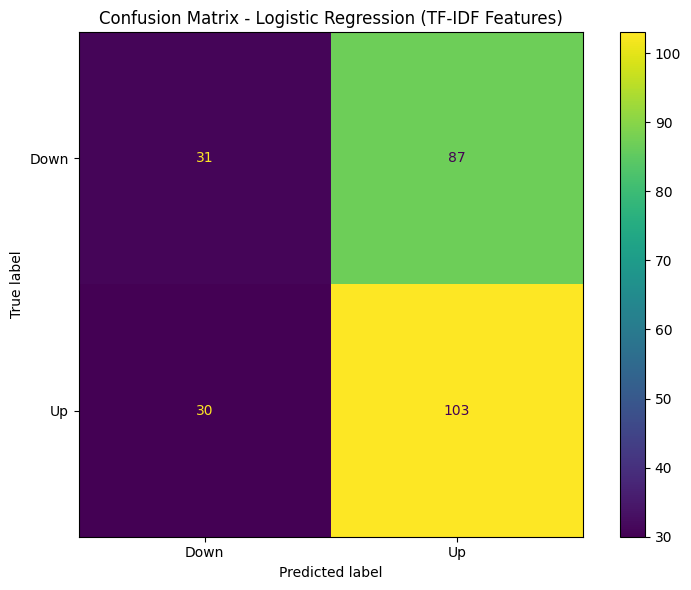

In [38]:
# Make predictions on validation set
y_pred_combined = lr_tfidf.predict(X_val_combined)

# Evaluate the model
print("Logistic Regression - TF-IDF Text Features Results")

# Accuracy
accuracy = accuracy_score(y_val_sentiment, y_pred_combined)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(CR(y_val_sentiment, y_pred_combined, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val_sentiment, y_pred_combined, labels=lr_tfidf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression (TF-IDF Features)")
plt.tight_layout()
plt.show()

In [39]:
def gridsearch_sentiment():
    # Define the hyperparameter grid to search
    param_grid_sentiment = {
        'C': [0.01, 0.1, 1, 10],           # Regularization strength
        'max_iter': [200, 500, 1000],      # Maximum iterations
        'solver': ['lbfgs', 'liblinear'],  # Optimization algorithm
        'penalty': ['l2']                   # Regularization type
    }
    
    # Initialize the logistic regression model
    lr_base = LR(random_state=42)
    
    # Set up GridSearchCV with cross-validation
    grid_search_sentiment = GridSearchCV(
        estimator=lr_base,
        param_grid=param_grid_sentiment,
        cv=5,                              # 5-fold cross-validation
        scoring='accuracy',
        verbose=1
    )
    
    # Fit grid search on training data
    print("Starting Grid Search for Logistic Regression on TF-IDF Features...")
    grid_search_sentiment.fit(X_train_combined, y_train_sentiment)
    
    # Display best parameters and score
    print("Grid Search Results - Sentiment Dataset (TF-IDF)")
    print(f"\nBest Parameters: {grid_search_sentiment.best_params_}")
    print(f"Best Cross-Validation Accuracy: {grid_search_sentiment.best_score_:.4f}")

    # Get the best estimator and CV results
    cv_results = grid_search_sentiment.cv_results_
    
    # Create a results table for each parameter combination
    results_data = []
    
    for i, params in enumerate(cv_results['params']):
        # Create a model with these parameters
        model = LR(**params, random_state=42)
        model.fit(X_train_tfidf, y_train_sentiment)
        
        # Training predictions and metrics
        y_train_pred = model.predict(X_train_tfidf)
        train_acc = accuracy_score(y_train_sentiment, y_train_pred)
        train_f1 = f1_score(y_train_sentiment, y_train_pred, average='weighted')
        
        # Validation predictions and metrics
        y_val_pred = model.predict(X_val_tfidf)
        val_acc = accuracy_score(y_val_sentiment, y_val_pred)
        val_f1 = f1_score(y_val_sentiment, y_val_pred, average='weighted')
        
        results_data.append({
            'C': f"{params['C']:g}",
            'Max Iterations': params['max_iter'],
            'Training Accuracy': f"{train_acc:.3%}",
            'Training F1': f"{train_f1:.3f}",
            'Validation Accuracy': f"{val_acc:.3%}",
            'Validation F1': f"{val_f1:.3f}"
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(results_data)
    
    # Sort by C (descending) and Max Iterations (ascending)
    results_df = results_df.sort_values(['C', 'Max Iterations'], ascending=[False, True]).reset_index(drop=True)

    best_lr_sentiment = grid_search_sentiment.best_estimator_

    #delete grid search to save memory
    del grid_search_sentiment
    gc.collect()

    return results_df, best_lr_sentiment

results_df, best_lr_sentiment = gridsearch_sentiment()

# Display styled table
results_df.style.set_caption("Logistic Regression (TF-IDF Sentiment Dataset)").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
])

Starting Grid Search for Logistic Regression on TF-IDF Features...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Grid Search Results - Sentiment Dataset (TF-IDF)

Best Parameters: {'C': 0.01, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.5283


,C,Max Iterations,Training Accuracy,Training F1,Validation Accuracy,Validation F1
0,10,200,76.500%,0.749,56.574%,0.561
1,10,200,76.500%,0.749,56.175%,0.557
2,10,500,76.500%,0.749,56.574%,0.561
3,10,500,76.500%,0.749,56.175%,0.557
4,10,1000,76.500%,0.749,56.574%,0.561
5,10,1000,76.500%,0.749,56.175%,0.557
6,1,200,70.419%,0.678,53.785%,0.504
7,1,200,70.419%,0.678,53.386%,0.498
8,1,500,70.419%,0.678,53.785%,0.504
9,1,500,70.419%,0.678,53.386%,0.498


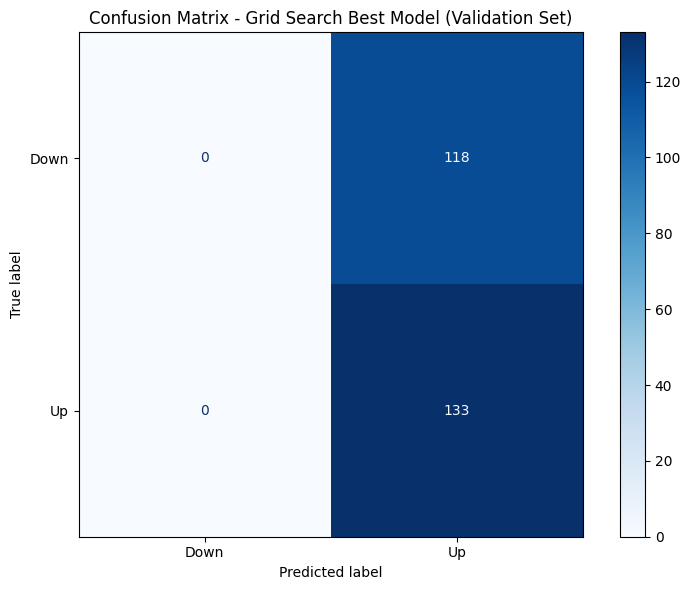

In [40]:
# Get the best model and make predictions on validation set
y_pred_val = best_lr_sentiment.predict(X_val_combined)

# Create and plot confusion matrix
cm = confusion_matrix(y_val_sentiment, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Grid Search Best Model (Validation Set)')
plt.tight_layout()
plt.show()

All observations were predicted as the "increase" stock price prediction class. This model achieved a 53% accuracy, which we can use as a future baseline. All model should ideally score at least 53% accuracy. This makes sense, since there are slightly more observations with the "increase" label than the "decrease" label, as noted in an earlier section.

## Price Dataset

First, a base logistic regression built with the training data from the price dataset.

In [41]:
def fit_model_price(model, train_dataset, val_dataset,
              target_var="Stock Price Direction", print_matrix=True):
    """Fit on train, evaluate on val."""

    train_X = train_dataset.drop(columns=[target_var], errors="ignore")
    train_y = train_dataset[target_var]
    val_X   = val_dataset.drop(columns=[target_var], errors="ignore")
    val_y   = val_dataset[target_var]

    #Drop datetime cols
    dt_cols = train_X.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns
    train_X = train_X.drop(columns=dt_cols)
    val_X   = val_X.drop(columns=dt_cols, errors="ignore")

    #Fit + predict
    model.fit(train_X, train_y)
    my_pred = model.predict(val_X)

    print(f"Model: {model}")
    print(CR(my_pred, val_y))

    #Confusion matrix
    cm = confusion_matrix(val_y, my_pred, labels=model.classes_)

    if print_matrix:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        fig, ax = plt.subplots(figsize=(12, 12))
        disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)

        for row in disp.text_:
            for text in row:
                text.set_fontsize(20)

        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

Model: LogisticRegression(C=1, max_iter=500, random_state=42)
              precision    recall  f1-score   support

        Down       0.14      0.55      0.23        31
          Up       0.89      0.54      0.67       220

    accuracy                           0.54       251
   macro avg       0.52      0.54      0.45       251
weighted avg       0.80      0.54      0.62       251



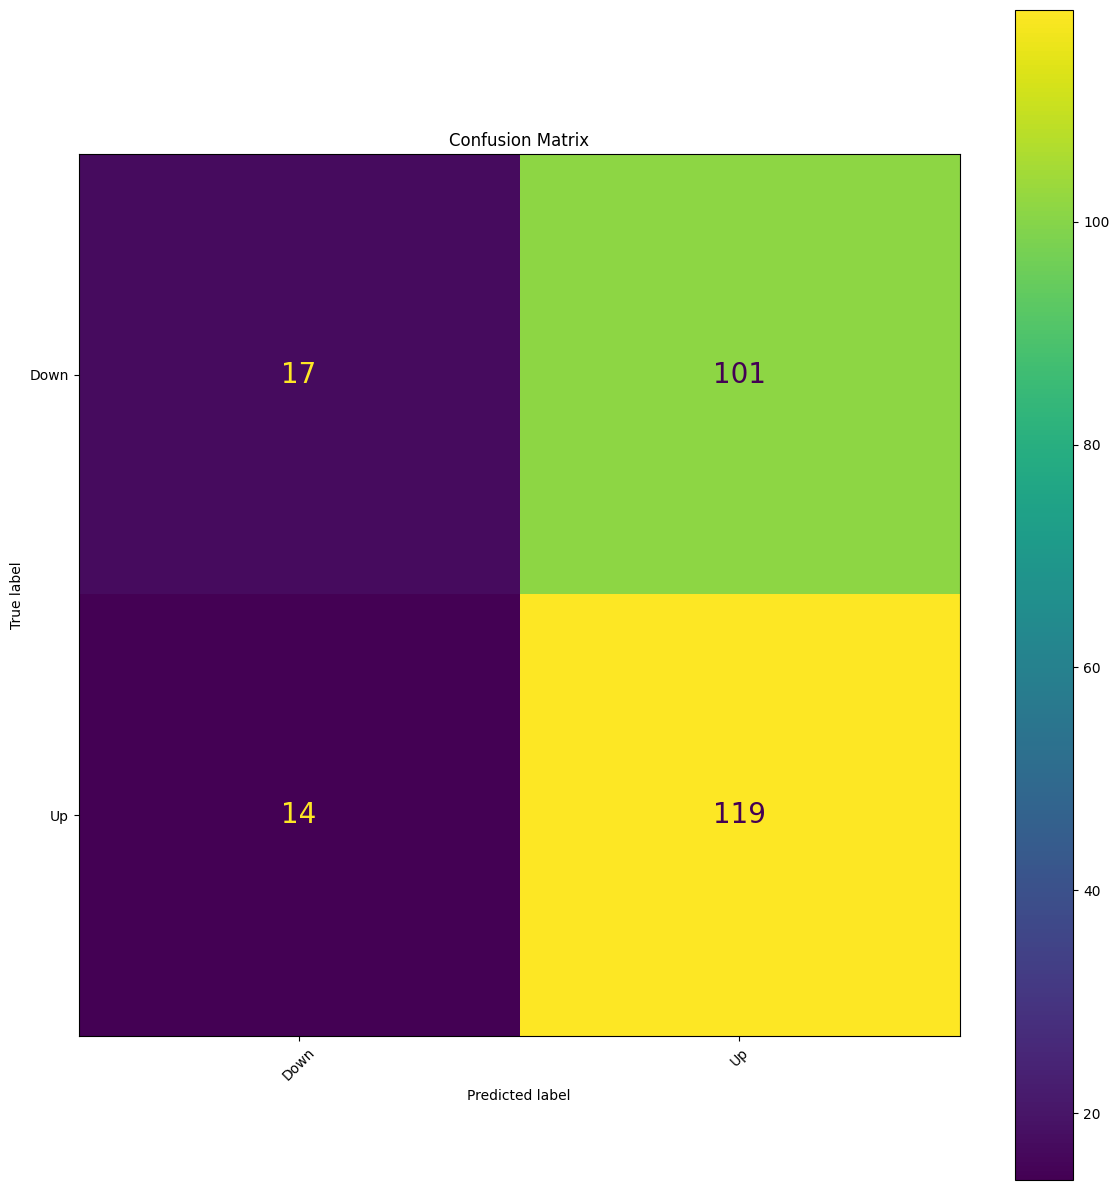

In [42]:
#Logistic Regression for the price dataset
price_lr=LR(max_iter=500, C=1, random_state=42) #Logistic Regression
fit_model_price(price_lr, cleaned_ts_train, cleaned_ts_val)

Next, hyperparameters are specified to optimize the logistic regression's model performance.

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ................................C=0.1, max_iter=200; total time=   0.1s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.1s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.1s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.1s
[CV] END ...............................C=0.1, max_iter=1000; total time=   0.0s
[CV] END ...............................C=0.1, ma

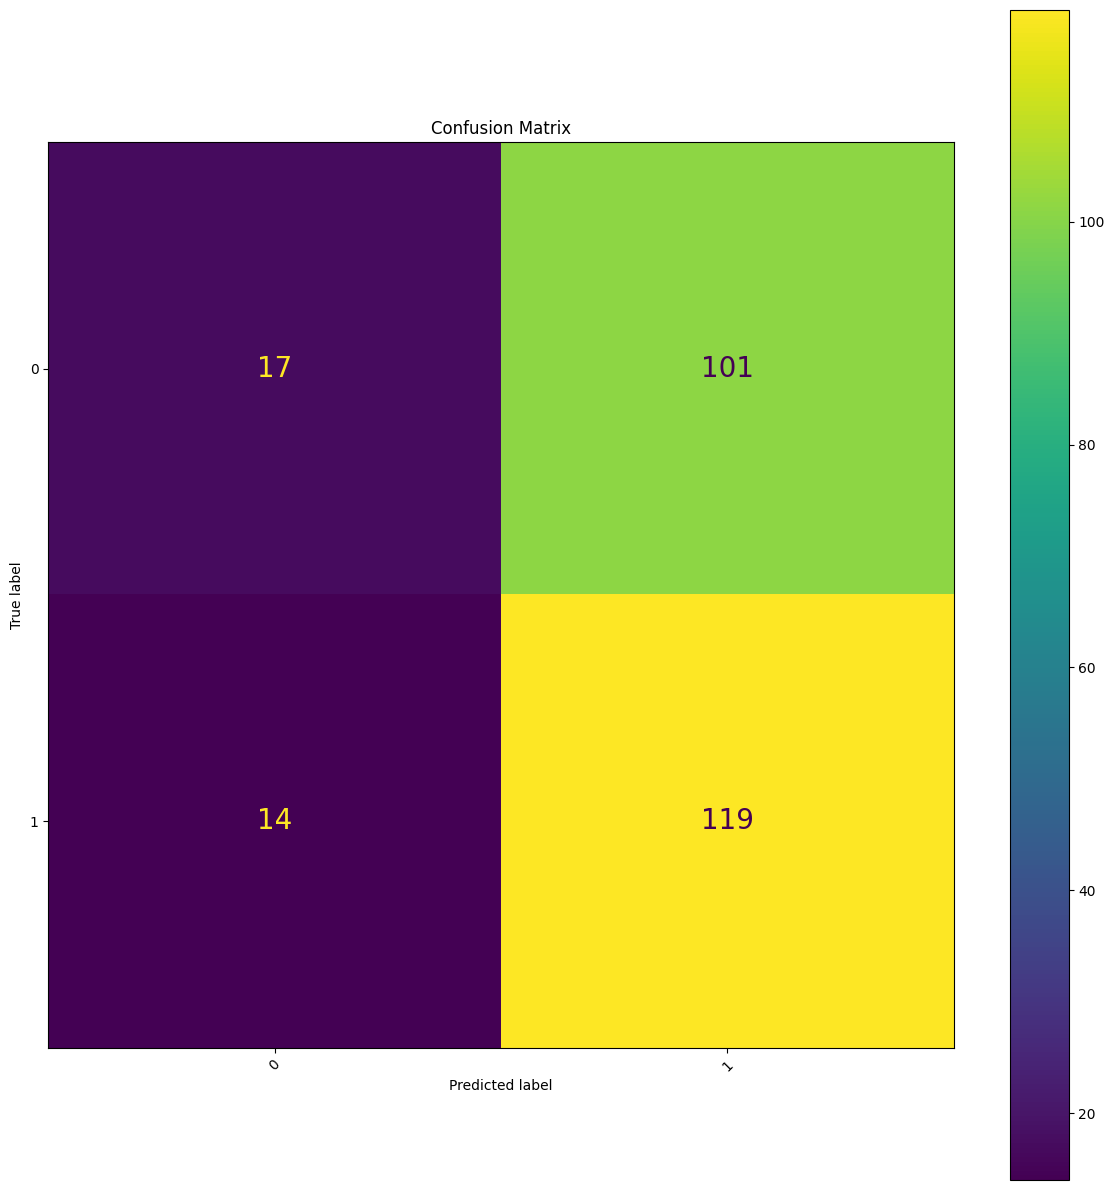

In [43]:
#need to convert categorical target variable to numerical
if (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_ts_train['Stock Price Direction'] = cleaned_ts_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_val['Stock Price Direction']   = cleaned_ts_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_test['Stock Price Direction']   = cleaned_ts_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})


# Define the hyperparameter grid to search
param_grid = {
    'max_iter':[200, 500, 1000],    # number of iterations for model
    'C': [0.1, 1, 5]                # regularization strength
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, pos_label=1)   # or pos_label=1 if encoded
}


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=price_lr, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'f1',
    return_train_score=True
)

# Fit to training data
train_X = cleaned_com_train.drop(columns = ['Stock Price Direction'])
train_y = cleaned_com_train['Stock Price Direction']
grid_search.fit(train_X, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_accuracy', ascending=False))


# Best model
best_price_lr = grid_search.best_estimator_

price_lr_tuned = LR(max_iter = grid_search.best_params_['max_iter'],
           C = grid_search.best_params_['C'], 
           random_state = 42
        )

fit_model_price(price_lr_tuned, cleaned_ts_train, cleaned_ts_val)

According to the results, tuning does very little to improve the logistic regression's performance on the price dataset. 

## Combined Dataset

In [44]:
#Model Selection
def fit_model(model, train_dataset, val_dataset, target_var = 'Stock Price Direction', print_matrix = True):
    '''General function to fit model on training set, evaluate on validation set, and produce confusion matrix'''
    
    train_X = train_dataset.drop(columns = [target_var])
    train_y = train_dataset[target_var]
    val_X = val_dataset.drop(columns = [target_var])
    val_y = val_dataset[target_var]
    
    #Fit model on training dataset
    model.fit(train_X, train_y)

    #Generate predictions and produce accuracy metrics
    my_pred = model.predict(val_X)
    print(f'Model: {model}')
    print(CR(my_pred, val_y))

    #generate confusion matrix
    cm = confusion_matrix(val_y, my_pred, labels=model.classes_)

    #print confusion matrix
    if print_matrix:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
        fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size for readability
        disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)

        for row in disp.text_:
            for text in row:
                text.set_fontsize(20)


        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

Model: LogisticRegression(C=1, l1_ratio=0, max_iter=500, random_state=42)
              precision    recall  f1-score   support

        Down       0.30      0.46      0.36        74
          Up       0.70      0.53      0.61       172

    accuracy                           0.51       246
   macro avg       0.50      0.50      0.48       246
weighted avg       0.58      0.51      0.53       246



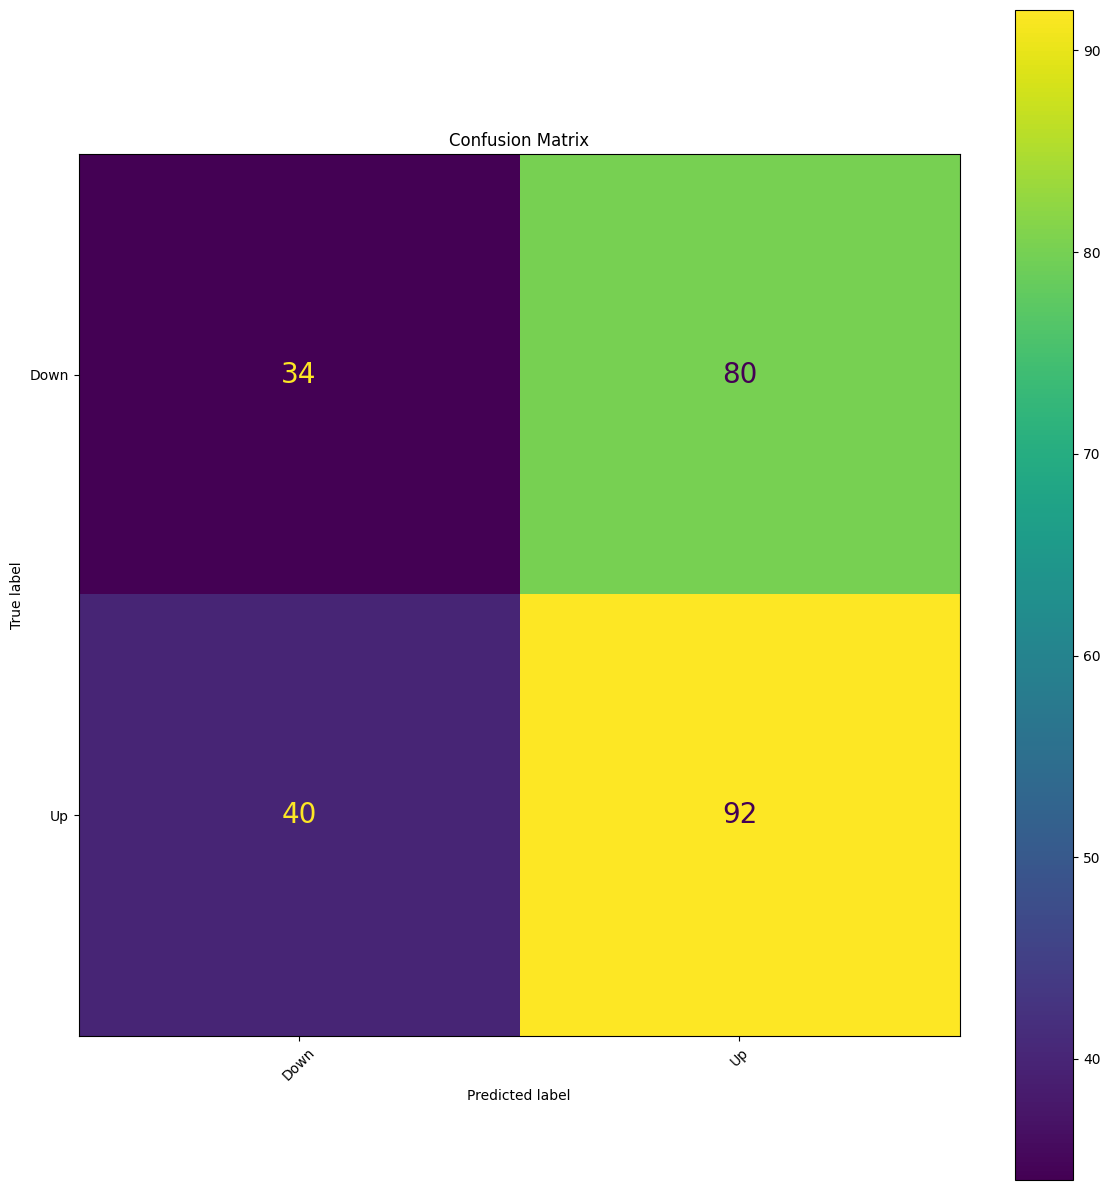

In [45]:
#Logistic Regression for the combined dataset
lr=LR(l1_ratio=0, max_iter=500, C=1, random_state=42) #Logistic Regression
fit_model(lr, cleaned_com_train, cleaned_com_val)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ...............................C=0.1, max_iter=1000; total time=   0.1s
[CV] END ...............................C=0.1, ma

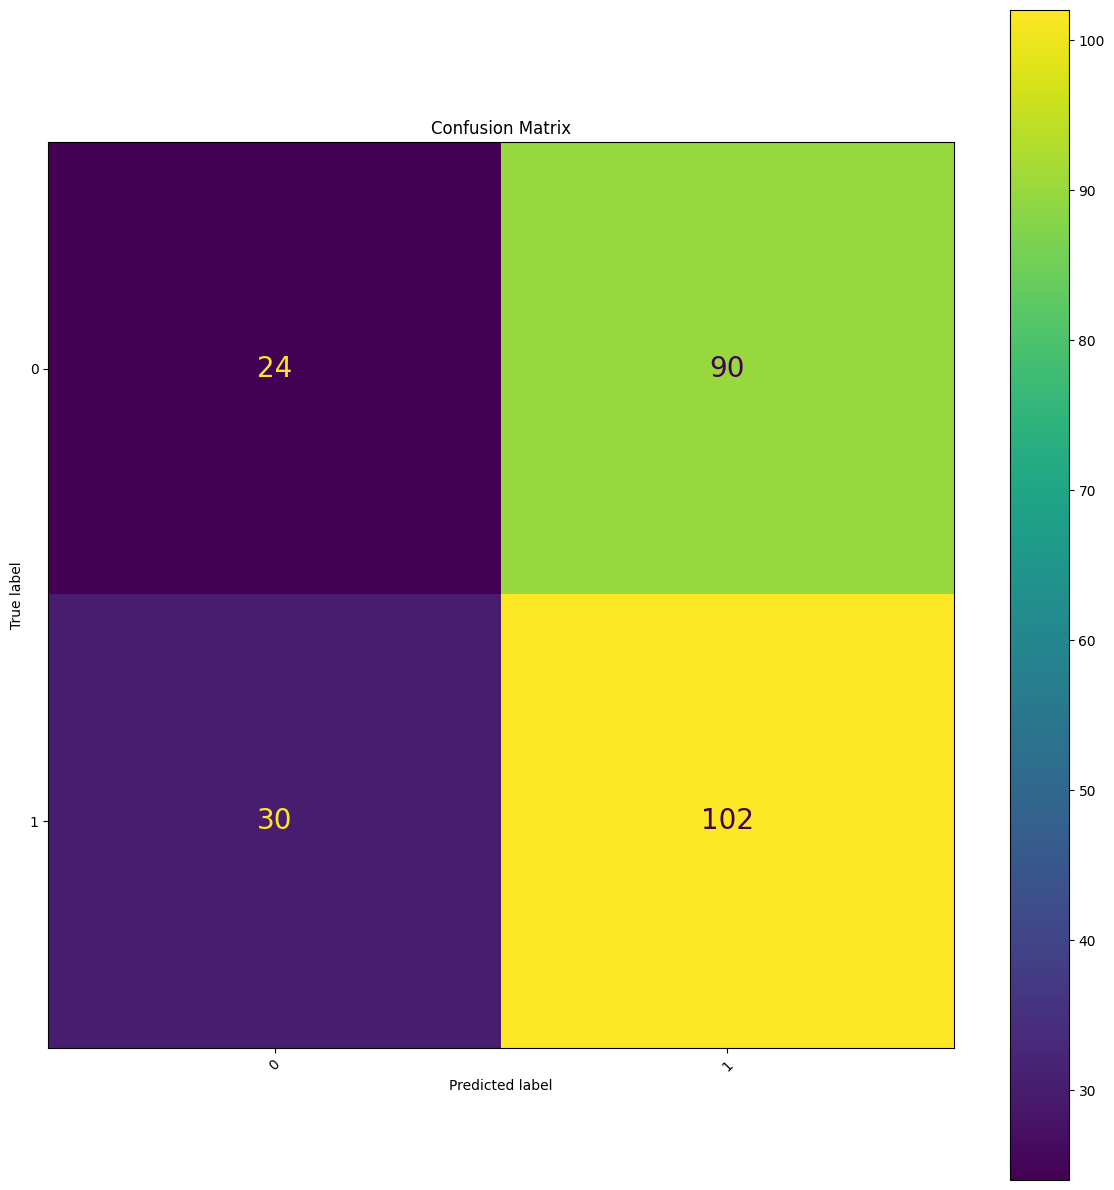

In [46]:
#need to convert categorical target variable to numerical
if (cleaned_com_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_com_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_com_train['Stock Price Direction'] = cleaned_com_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_com_val['Stock Price Direction']   = cleaned_com_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_com_test['Stock Price Direction']   = cleaned_com_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})


# Define the hyperparameter grid to search
param_grid = {
    'max_iter':[200, 500, 1000],    # number of iterations for model
    'C': [0.1, 1, 5]                # regularization strength
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, pos_label=1)   # or pos_label=1 if encoded
}


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=lr, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'f1',
    return_train_score=True,
    verbose=2
)

# Fit to training data
train_X = cleaned_com_train.drop(columns = ['Stock Price Direction'])
train_y = cleaned_com_train['Stock Price Direction']
grid_search.fit(train_X, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_accuracy', ascending=False))


# Best model
best_lr = grid_search.best_estimator_

lr2 = LR(max_iter = grid_search.best_params_['max_iter'],
           C = grid_search.best_params_['C'], 
           random_state = 42
        )

fit_model(lr2, cleaned_com_train, cleaned_com_val)

This model is performing slightly better than 50/50 with 51% accuracy. Our goal at the beginning of the project is 52% accuracy, so this is slightly below. F1 score on the "up" stock price direction is better than "down", this is likely because there were more up days in the training dataset. Precision was much better on the "up" direction than down, and recall was slightly higher for "up".

## Support Vector Machine (SVM)

we selected a slightly more complex model (compared to the logistic regression from the previous week) in support vector machines (SVMs). SVMs strive to find the optimal hyperplane that separates the “up” and “down” classes with as minimal error as possible. They are able to use different kernels, which can capture non-linear relationships between variables. SVMs also tend to perform well with NLP datasets, hence the reasoning to use it on the sentiment and combined datasets in particular. In this section, a support vector machine model will be implemented across all three datasets.

## Sentiment Dataset


Accuracy: 0.5259

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.14      0.21       118
      Up (1)       0.53      0.87      0.66       133

    accuracy                           0.53       251
   macro avg       0.51      0.50      0.44       251
weighted avg       0.51      0.53      0.45       251


Confusion Matrix:


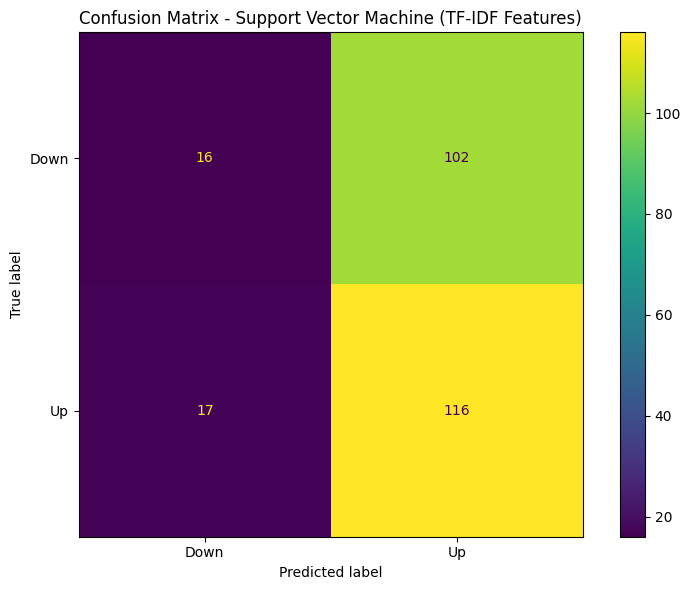

In [47]:
# Base SVM for Sentiment Dataset
svm_sentiment = SVC(kernel='linear', C=1, random_state=42)
svm_sentiment.fit(X_train_combined, y_train_sentiment)

# Make predictions on validation set
y_pred_svm = svm_sentiment.predict(X_val_combined)

# Accuracy
accuracy = accuracy_score(y_val_sentiment, y_pred_svm)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(CR(y_val_sentiment, y_pred_svm, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val_sentiment, y_pred_svm, labels=svm_sentiment.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Support Vector Machine (TF-IDF Features)")
plt.tight_layout()
plt.show()

In [48]:
# Define the hyperparameter grid for SVM
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'kernel': ['linear', 'rbf'],      # Kernel type
    'gamma': ['scale', 'auto']        # Kernel coefficient for 'rbf'
}

# Define scoring metrics for GridSearchCV
scoring_svm = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score, pos_label=1)
}

# Initialize the SVM model
svm_model = SVC(max_iter=5000,random_state=42)

# Set up GridSearchCV with cross-validation
grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,                              # 5-fold cross-validation
    scoring=scoring_svm,
    refit='f1',                       # Refit using F1 score
)

# Fit grid search on training data
print("Starting Grid Search for Support Vector Machine on Sentiment TF-IDF Features...")
grid_search_svm.fit(X_train_combined, y_train_sentiment)

Starting Grid Search for Support Vector Machine on Sentiment TF-IDF Features...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(max_iter=...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f..., pos_label=1)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

Best Hyperparameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
                                               params  mean_test_accuracy  \
0   {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}            0.528348   
1      {'C': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}            0.528348   
2    {'C': 0.01, 'gamma': 'auto', 'kernel': 'linear'}            0.528348   
3       {'C': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
4    {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}            0.528348   
5       {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}            0.528348   
6     {'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}            0.528348   
7        {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
11         {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
15        {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
9         {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}            0.511064   
12  

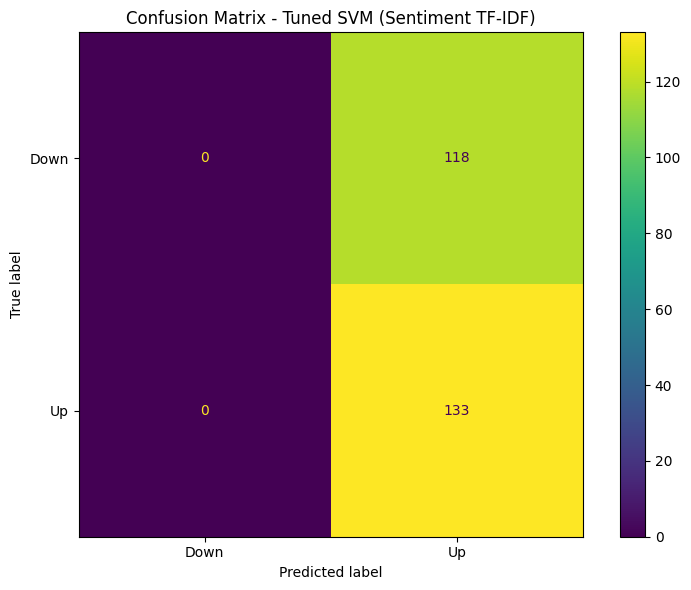

In [49]:
# Get the best estimator from grid search
best_sentiment_svm = grid_search_svm.best_estimator_

# Evaluate best model on validation set
y_pred_val = best_sentiment_svm.predict(X_val_combined)

print("\n--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(y_val_sentiment, y_pred_val):.4f}")
print("\nClassification Report:")
print(CR(y_val_sentiment, y_pred_val, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
cm = confusion_matrix(y_val_sentiment, y_pred_val, labels=best_sentiment_svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Tuned SVM (Sentiment TF-IDF)")
plt.tight_layout()
plt.show()

Similar to the logistic model with the sentiment dataset, all predictions belong to one class. This has identical performance with 53% accuracy. 

## Price Dataset

Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(class_weight='balanced', random_state=42))])
              precision    recall  f1-score   support

           0       0.61      0.44      0.51       163
           1       0.32      0.48      0.38        88

    accuracy                           0.45       251
   macro avg       0.46      0.46      0.45       251
weighted avg       0.51      0.45      0.47       251



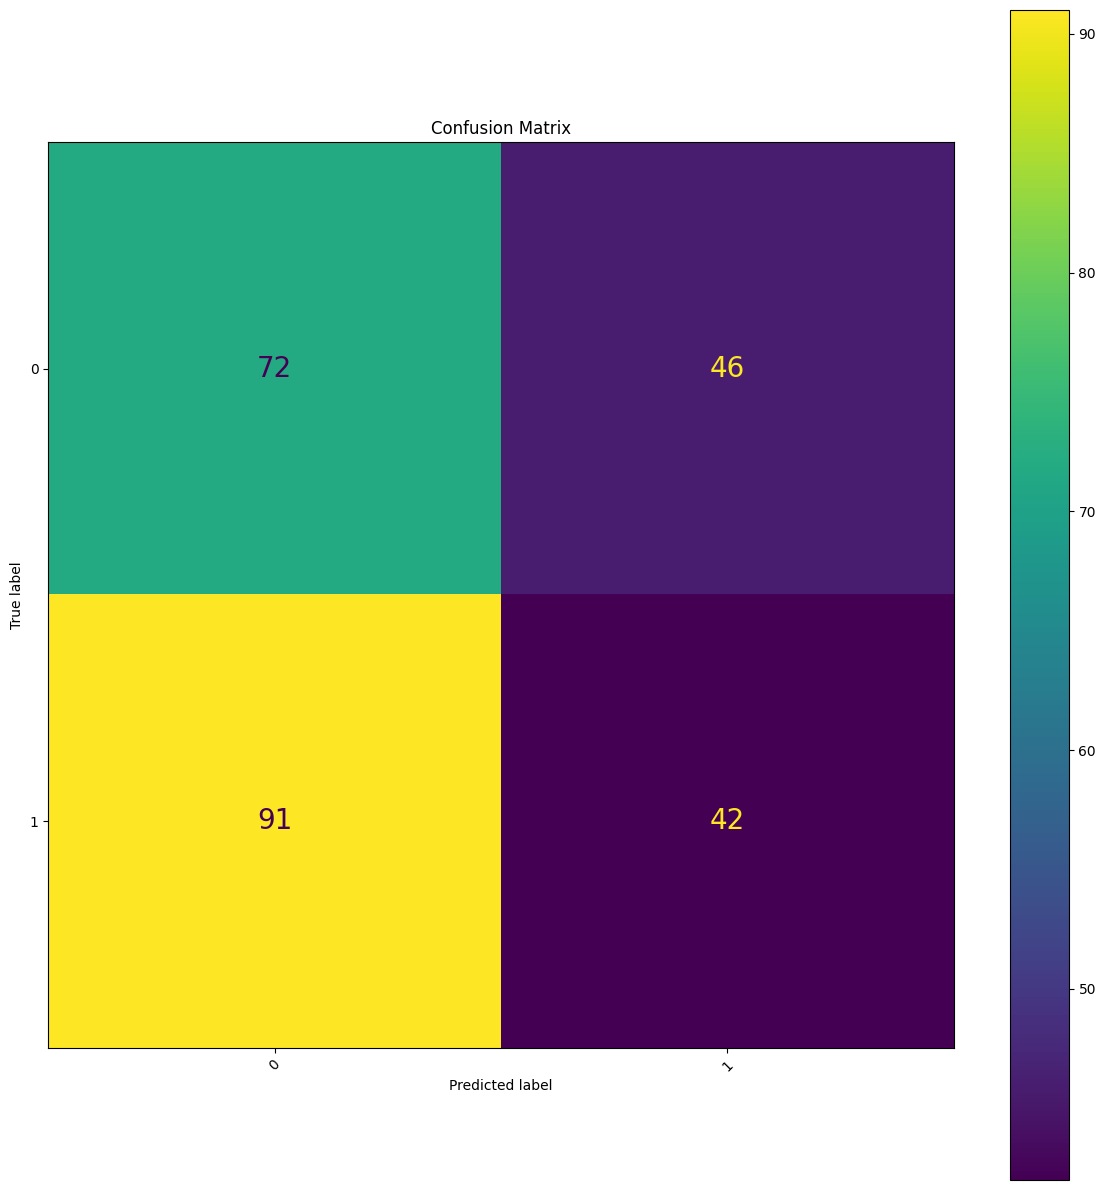

In [50]:
# Support Vector Machine for Price Prediction
price_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

fit_model_price(price_svm, cleaned_ts_train, cleaned_ts_val)

Grid search to tune hyperparameters and find optimal combination.

Best Hyperparameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=0.1, class_weight='balanced', kernel='linear',
                     random_state=42))])
              precision    recall  f1-score   support

           0       0.49      0.45      0.47       130
           1       0.46      0.50      0.48       121

    accuracy                           0.47       251
   macro avg       0.48      0.48      0.47       251
weighted avg       0.48      0.47      0.47       251



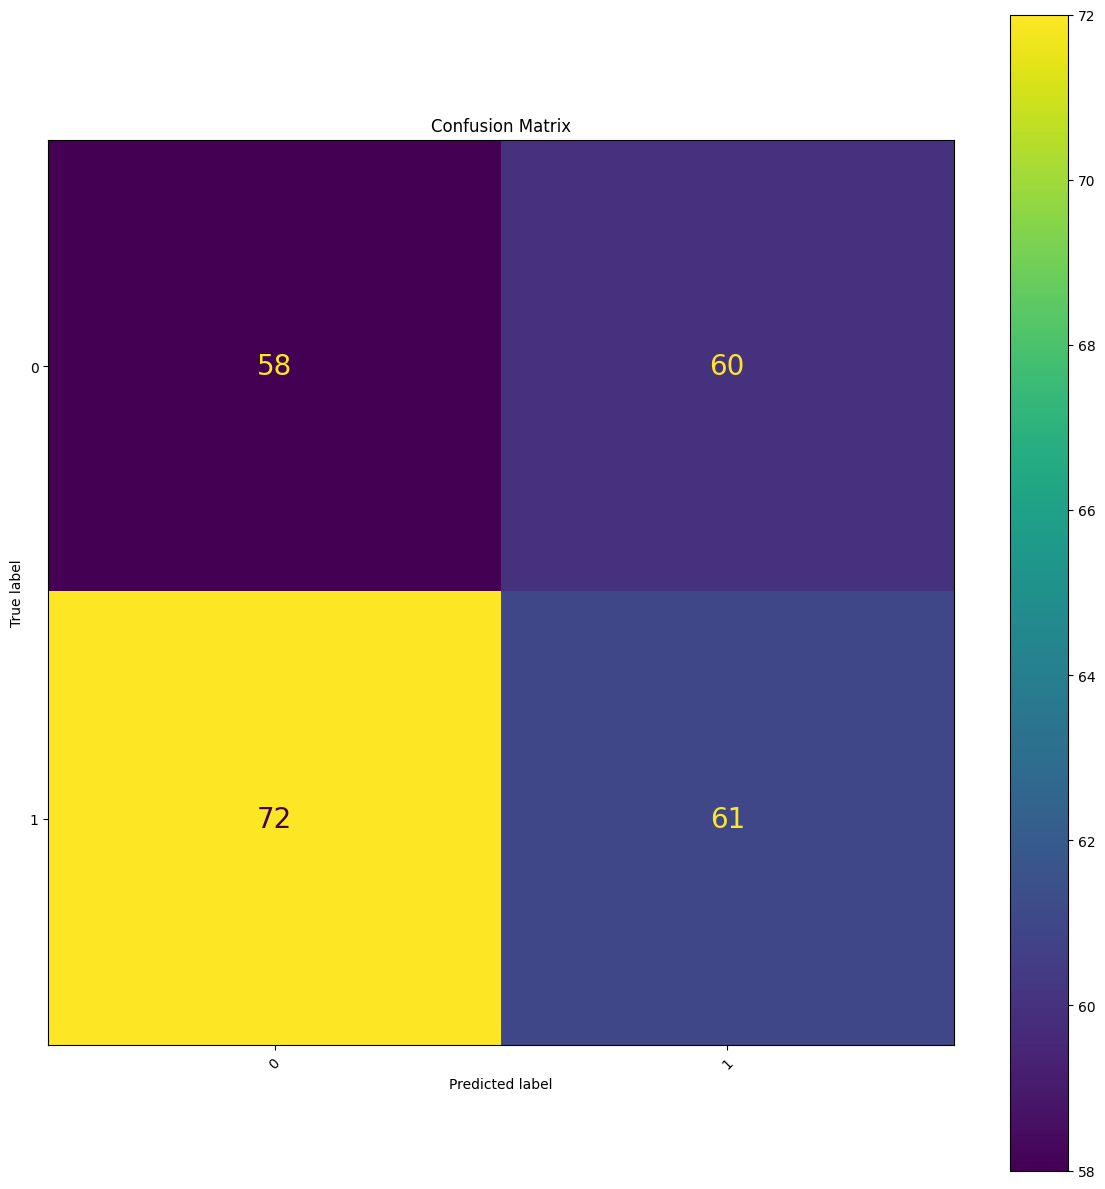

In [51]:
# Convert categorical target variable to numerical
if (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_ts_train['Stock Price Direction'] = cleaned_ts_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_val['Stock Price Direction']   = cleaned_ts_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_test['Stock Price Direction']  = cleaned_ts_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})

# Define the hyperparameter grid for SVM
param_grid = {
    'svm__C':      [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 'auto']
}

# Define scoring metrics for GridSearchCV
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score, pos_label=1)
}

# Create a pipeline for SVM with scaling
price_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

# Set up GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=price_svm,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit='f1',
    return_train_score=True
)

# Fit the grid search on the training data
price_train_X = cleaned_ts_train.drop(columns=['Stock Price Direction', 'Dates'])
price_train_y = cleaned_ts_train['Stock Price Direction']
grid_search.fit(price_train_X, price_train_y)

# Display best hyperparameters and cross-validation results
print("Best Hyperparameters:", grid_search.best_params_)

best_price_svm = grid_search.best_estimator_

price_svm_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=grid_search.best_params_['svm__C'],
        kernel=grid_search.best_params_['svm__kernel'],
        gamma=grid_search.best_params_['svm__gamma'],
        class_weight='balanced',
        random_state=42
    ))
])

fit_model_price(price_svm_tuned, cleaned_ts_train, cleaned_ts_val)

The performance metrics also show that the SVM did not perform well at predicting stock price directions in the historical price dataset. This, combined with the results from the logistic regression model last week, suggests that the features in the historical price data are weak at predicting stock price direction. While there is still another model that needs to be assessed, it is unlikely that the dataset creates strong predictions.

This model is poor, it has accuracy below 50%. It is worse than random guessing, so this model will not be used on the test dataset.

## Combined Dataset

Model: Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(random_state=42))])
              precision    recall  f1-score   support

           0       0.11      0.57      0.19        23
           1       0.92      0.55      0.69       223

    accuracy                           0.55       246
   macro avg       0.52      0.56      0.44       246
weighted avg       0.85      0.55      0.64       246



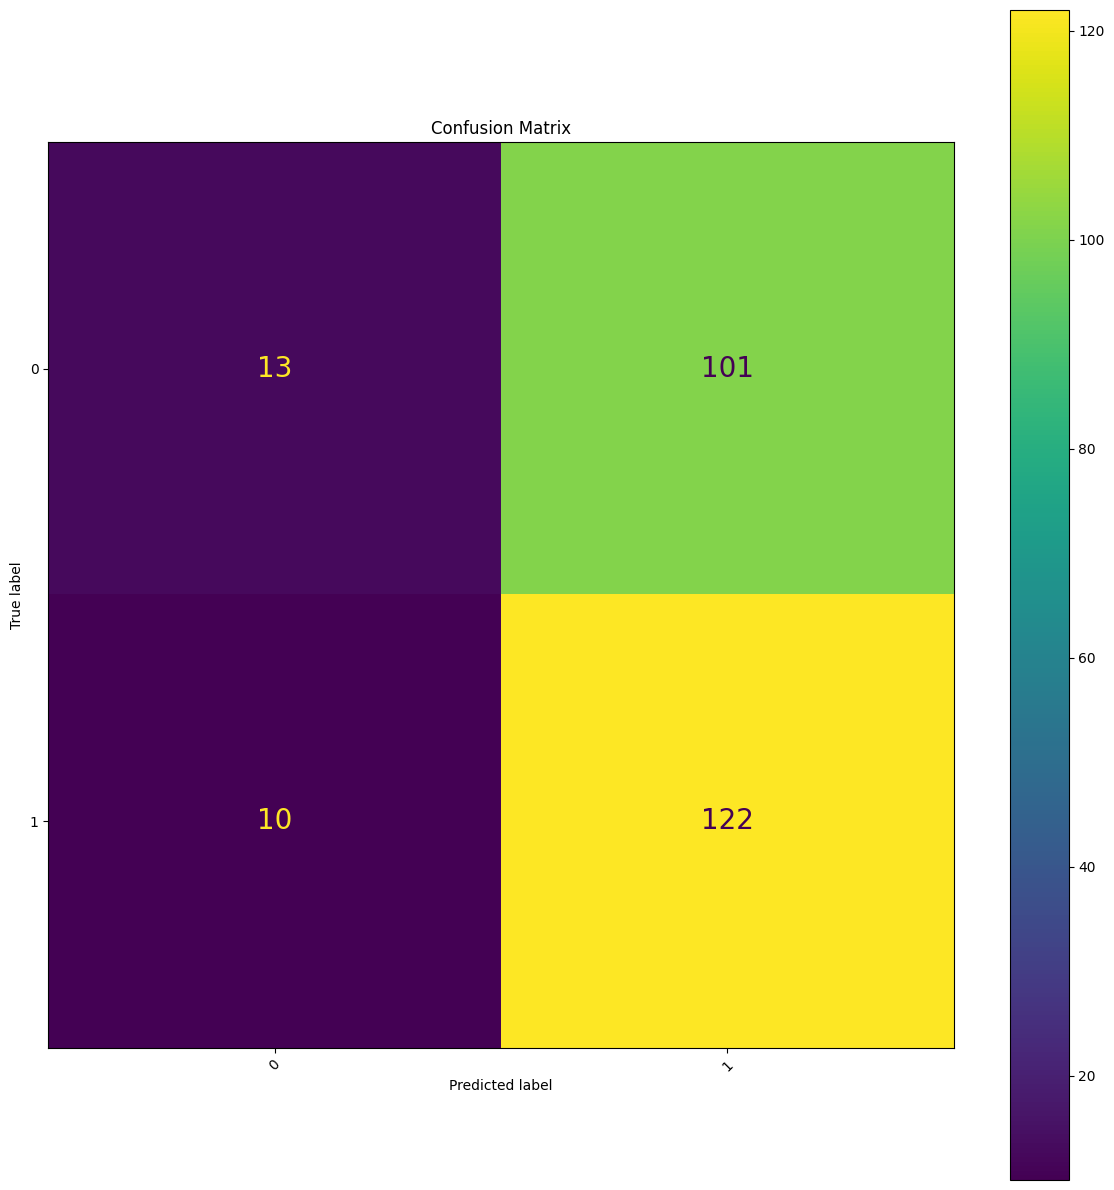

In [52]:
# Support Vector Machine for Combined Dataset
svm = SVC(random_state=42)
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

fit_model(svm, cleaned_com_train, cleaned_com_val)


Best Hyperparameters: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear', 'svc__max_iter': 1000}
Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=0.1, kernel='linear', max_iter=1000, random_state=42))])
              precision    recall  f1-score   support

           0       0.11      0.60      0.18        20
           1       0.94      0.55      0.69       226

    accuracy                           0.55       246
   macro avg       0.52      0.57      0.44       246
weighted avg       0.87      0.55      0.65       246



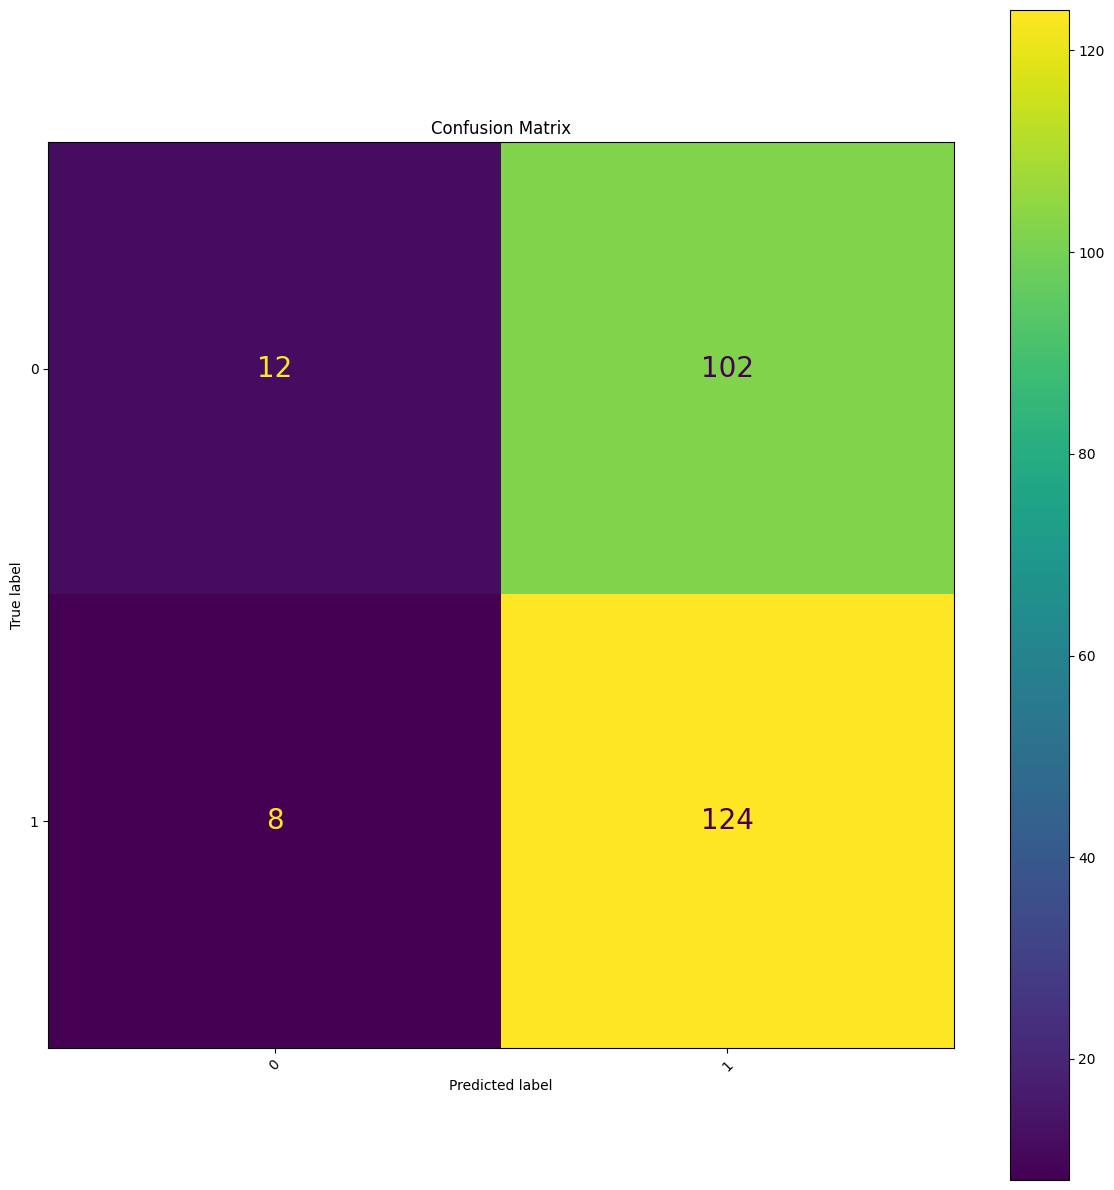

In [53]:
# Define the hyperparameter grid to search
param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'svc__C': [0.1, 1, 5],
    'svc__gamma': ['scale', 'auto'],
    'svc__max_iter': [1000, 2000]
}


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'accuracy',
    return_train_score=True
)

# Fit to training data
cleaned_com_train_df = pd.DataFrame(cleaned_com_train)
grid_search.fit(cleaned_com_train_df, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Best model
best_svm = grid_search.best_estimator_

fit_model(best_svm, cleaned_com_train, cleaned_com_val)

When tested across the entire validation dataset at once, the top model (the first row in the table above) achieved a 55% accuracy and .69 F1 score on the “up” direction class. This is closer to the expected performance, and is a step above the performance of the logistic regression (51% accuracy). 


## FinBERT Model

The FinBERT-based approach focused on enhancing text representation by generating finance-specific sentiment features from the full_text column and combining these with the existing sentiment variables (sentiment_pos, sentiment_neu, sentiment_neg, and sentiment_polarity) to predict next-period stock price direction. Rather than relying on TF-IDF representations, FinBERT was used to extract structured sentiment probabilities (positive, negative, and neutral), along with derived features such as polarity, which were then used as inputs into a logistic regression classifier. This approach leverages domain-specific language understanding, allowing the model to better capture financial tone and context embedded in news text while maintaining a lightweight and CPU-friendly modeling pipeline.

### Sentiment Dataset

In [54]:
# Define the model name for FinBERT
MODEL_NAME = "ProsusAI/finbert"

# Load the tokenizer and model from Hugging Face Transformers
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
finbert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
finbert_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [55]:
# Function to get sentiment probabilities from FinBERT for a given text input
def finbert_sentiment_probs(text, max_length=512):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    with torch.no_grad():
        outputs = finbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).numpy()[0]
    labels = [finbert_model.config.id2label[i] for i in range(len(probs))]
    return dict(zip(labels, probs))

In [56]:
# Apply the function to the 'full_text' column of the training dataset to get sentiment probabilities
scores = Final_Raw_X_train["full_text"].fillna("").apply(finbert_sentiment_probs)

# Convert the list of dictionaries into a DataFrame and rename columns to indicate they are from FinBERT
score_sentiment = scores.apply(pd.Series)
score_sentiment.columns = [f"finbert_{c.lower()}" for c in score_sentiment.columns]

# Combine the original training dataset with the new FinBERT sentiment scores
finbert_df = pd.concat([Final_Raw_X_train, score_sentiment], axis=1)
finbert_df["finbert_polarity"] = finbert_df["finbert_positive"] - finbert_df["finbert_negative"]
finbert_df["finbert_confidence"] = finbert_df[[
    "finbert_positive", "finbert_negative", "finbert_neutral"
]].max(axis=1)

In [57]:
# Repeat the same process for the validation set
# Apply the function to the 'full_text' column of the validation dataset to get sentiment probabilities
scores_val = Final_Raw_X_val["full_text"].fillna("").apply(finbert_sentiment_probs)

# Convert the list of dictionaries into a DataFrame and rename columns to indicate they are from FinBERT
score_sentiment_val = scores_val.apply(pd.Series)
score_sentiment_val.columns = [f"finbert_{c.lower()}" for c in score_sentiment_val.columns]

# Combine the original validation dataset with the new FinBERT sentiment scores
finbert_val_df = pd.concat([Final_Raw_X_val, score_sentiment_val], axis=1)
finbert_val_df["finbert_polarity"] = finbert_val_df["finbert_positive"] - finbert_val_df["finbert_negative"]
finbert_val_df["finbert_confidence"] = finbert_val_df[["finbert_positive", "finbert_negative", "finbert_neutral"]].max(axis=1)

In [58]:
# Define the list of FinBERT feature columns for later use in modeling
full_finbert_feature_cols = [
    "finbert_positive", "finbert_negative", "finbert_neutral",
    "finbert_polarity", "finbert_confidence",
    "sentiment_pos", "sentiment_neg", "sentiment_neu", "sentiment_polarity"
]

In [59]:
# Prepare the training data for modeling
X_train_finbert1 = finbert_df[full_finbert_feature_cols]
y_train_finbert1 = finbert_df["Stock Price Direction"].map({"up": 1, "down": 0})
# Prepare the validation data for modeling
X_val_finbert1 = finbert_val_df[full_finbert_feature_cols]
y_val_finbert1 = finbert_val_df["Stock Price Direction"].map({"up": 1, "down": 0})

In [60]:
# Initialize and fit the logistic regression model
finbert_lr = LR(max_iter=500, C=1, random_state=42)
finbert_lr.fit(X_train_finbert1, y_train_finbert1)

# Make predictions on the validation set
y_pred_finbert = finbert_lr.predict(X_val_finbert1)
# Evaluate the model
print("Logistic Regression - FinBERT Sentiment Features Results")
# Accuracy
finbert_accuracy = accuracy_score(y_val_finbert1, y_pred_finbert)
print(f"\nAccuracy: {finbert_accuracy:.4f}")
# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(CR(y_val_finbert1, y_pred_finbert, target_names=['Down (0)', 'Up (1)']))

Logistic Regression - FinBERT Sentiment Features Results

Accuracy: 0.5578

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.56      0.26      0.36       118
      Up (1)       0.56      0.82      0.66       133

    accuracy                           0.56       251
   macro avg       0.56      0.54      0.51       251
weighted avg       0.56      0.56      0.52       251




Confusion Matrix:


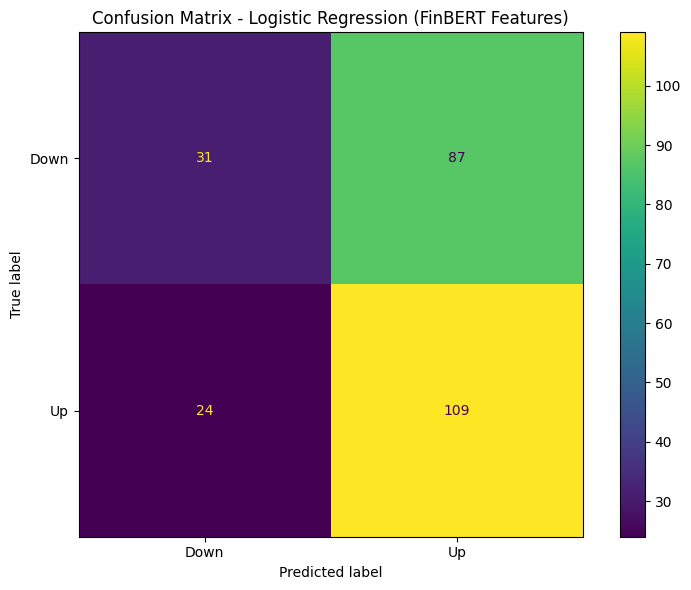

In [61]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val_finbert1, y_pred_finbert, labels=finbert_lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression (FinBERT Features)")
plt.tight_layout()
plt.show()

In [62]:
# Grid search on logistic regression for FinBERT + sentiment features

X_train_finbert_lr = X_train_finbert1.copy()
y_train_finbert_lr = y_train_finbert1.copy()
X_val_finbert_lr = X_val_finbert1.copy()
y_val_finbert_lr = y_val_finbert1.copy()

param_grid_lr = [
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'class_weight': [None, 'balanced']
    },
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1'],
        'solver': ['saga'],
        'class_weight': [None, 'balanced']
    },
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'class_weight': [None, 'balanced']
    }
]

grid_search_lr = GridSearchCV(
    LR(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',
    return_train_score=True
)

grid_search_lr.fit(X_train_finbert_lr, y_train_finbert_lr)

best_lr = grid_search_lr.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.1s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.1s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, pen


Logistic Regression GridSearch Results on Validation Set
Accuracy: 0.5418
Classification Report:
               precision    recall  f1-score   support

    Down (0)       0.54      0.16      0.25       118
      Up (1)       0.54      0.88      0.67       133

    accuracy                           0.54       251
   macro avg       0.54      0.52      0.46       251
weighted avg       0.54      0.54      0.47       251



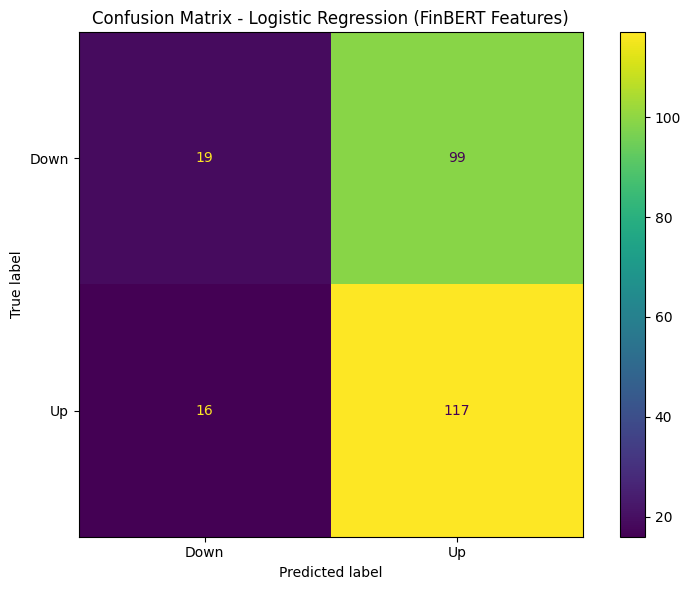

In [63]:
# Validation performance with best LR model
y_pred_val_lr = best_lr.predict(X_val_finbert_lr)

print("\nLogistic Regression GridSearch Results on Validation Set")
print(f"Accuracy: {accuracy_score(y_val_finbert_lr, y_pred_val_lr):.4f}")
print("Classification Report:\n", CR(y_val_finbert_lr, y_pred_val_lr, target_names=['Down (0)', 'Up (1)']))

cm_lr = confusion_matrix(y_val_finbert_lr, y_pred_val_lr, labels=best_lr.classes_)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Down', 'Up'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_lr.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression (FinBERT Features)")
plt.tight_layout()
plt.show()

## XGBoost Classifier

We decided to implement another complex model with a tree-based algorithm. XGBoost was a logical choice, as this model builds on the basic decision tree by implementing boosting, a method that uses each prior decision tree to inform the next. The model also uses gradient descent, which attempts to minimize the loss in the model’s performance over the iterations. This gives it similar attractive properties as a neural network, but it requires less data to train on, which is attractive for our project since we only have approximately two thousand observations in the combined dataset.  

### Historical Price Dataset

Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.36      0.40      0.38       107
           1       0.52      0.48      0.50       144

    accuracy                           0.45       251
   macro avg  

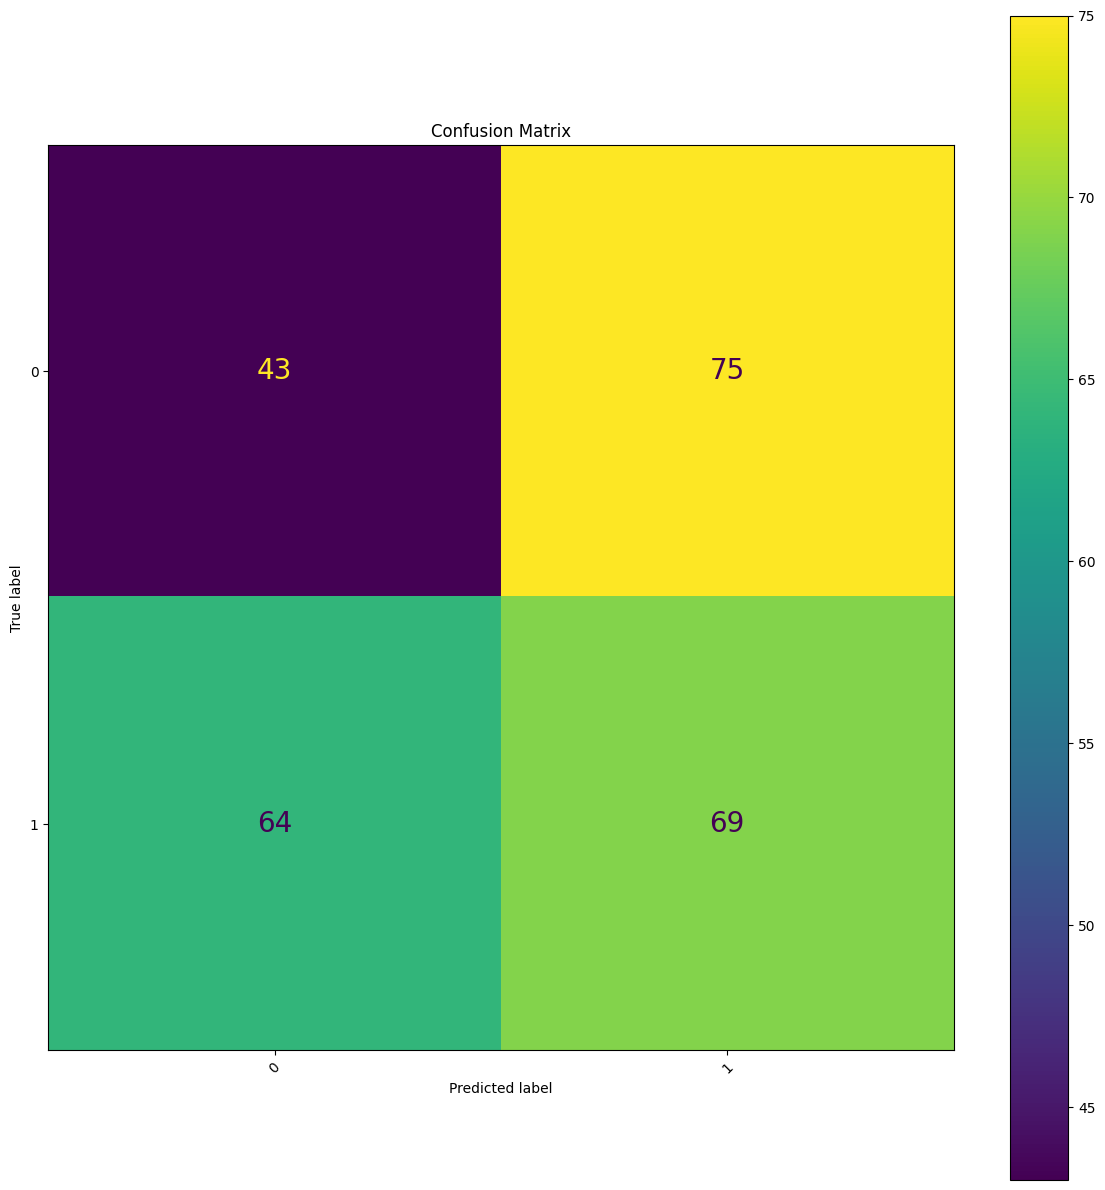

In [64]:
# Initial XGBoost model
xgb_model = XGBClassifier(random_state=42)

fit_model_price(xgb_model, cleaned_ts_train, cleaned_ts_val)

Model: Pipeline(steps=[('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_st

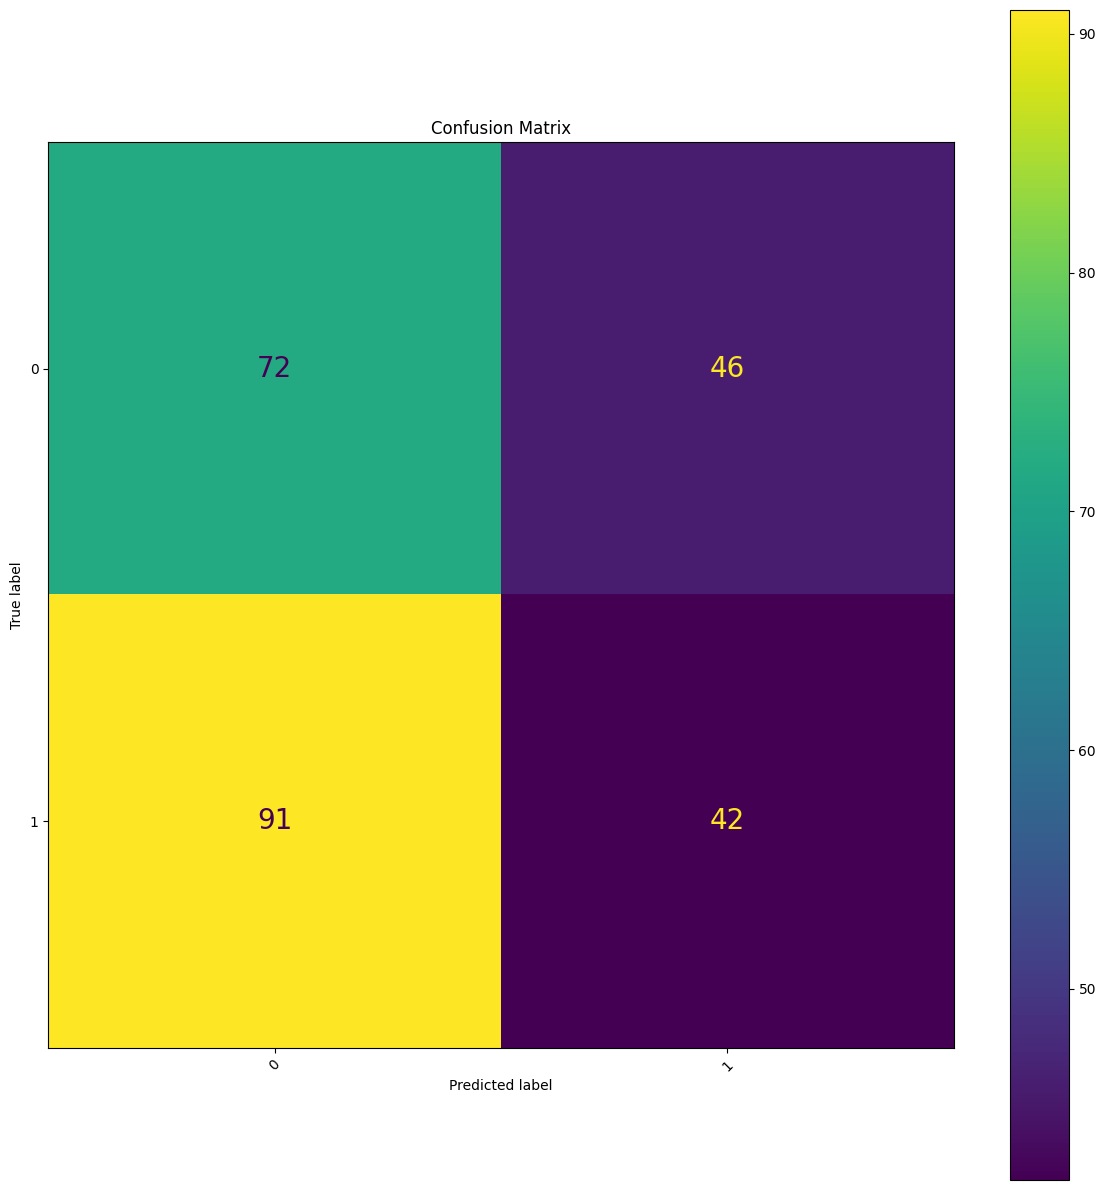

In [65]:
# Grid Search for hyperparamter tuning
if (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_ts_train['Stock Price Direction'] = cleaned_ts_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_val['Stock Price Direction']   = cleaned_ts_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_test['Stock Price Direction']  = cleaned_ts_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})

param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score, pos_label=1)
}

price_xgb = Pipeline([
    ('xgb', XGBClassifier(
        scale_pos_weight=len(train_y[train_y==0]) / len(train_y[train_y==1]),  # replaces class_weight='balanced'
        eval_metric='logloss',
        random_state=42
    ))
])

grid_search = RandomizedSearchCV(
    estimator=price_xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring=scoring,
    refit='f1',
    return_train_score=True,
    random_state=42
)

price_train_X = cleaned_ts_train.drop(columns=['Stock Price Direction', 'Dates'])
price_train_y = cleaned_ts_train['Stock Price Direction']
grid_search.fit(price_train_X, price_train_y)

price_xgb_tuned = Pipeline([
    ('xgb', XGBClassifier(
        n_estimators=grid_search.best_params_['xgb__n_estimators'],
        max_depth=grid_search.best_params_['xgb__max_depth'],
        learning_rate=grid_search.best_params_['xgb__learning_rate'],
        scale_pos_weight=len(price_train_y[price_train_y==0]) / len(price_train_y[price_train_y==1]),
        eval_metric='logloss',
        random_state=42
    ))
])

fit_model_price(price_xgb_tuned, cleaned_ts_train, cleaned_ts_val)

The results indicate that hyperparameter tuning provides little improvement in the performance of the XGBoost model. Since none of the models performed well using the historical price dataset, it is likely that the dataset lacks sufficient predictive information. The feature set is relatively small and simplistic, limiting its ability to effectively predict stock price direction.

## Combined Dataset

Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.50      0.49      0.49       117
           1       0.55      0.56      0.55       129

    accuracy                           0.52       246
   macro avg  

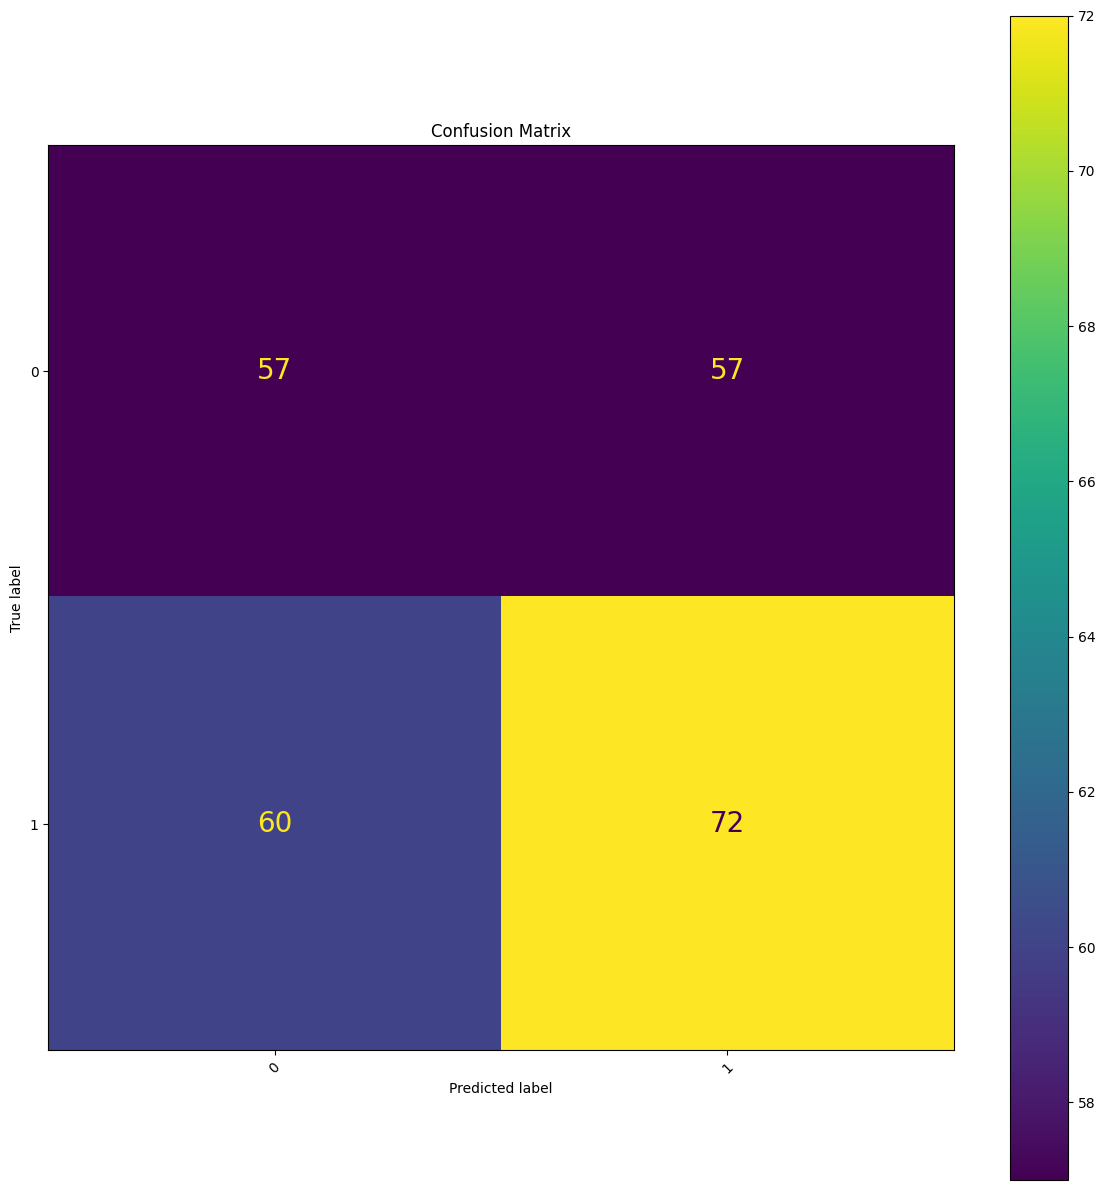

In [66]:
# XGBoost for Combined Dataset
xgb_boost = XGBClassifier(random_state=42)

fit_model(xgb_boost, cleaned_com_train, cleaned_com_val)


Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                    

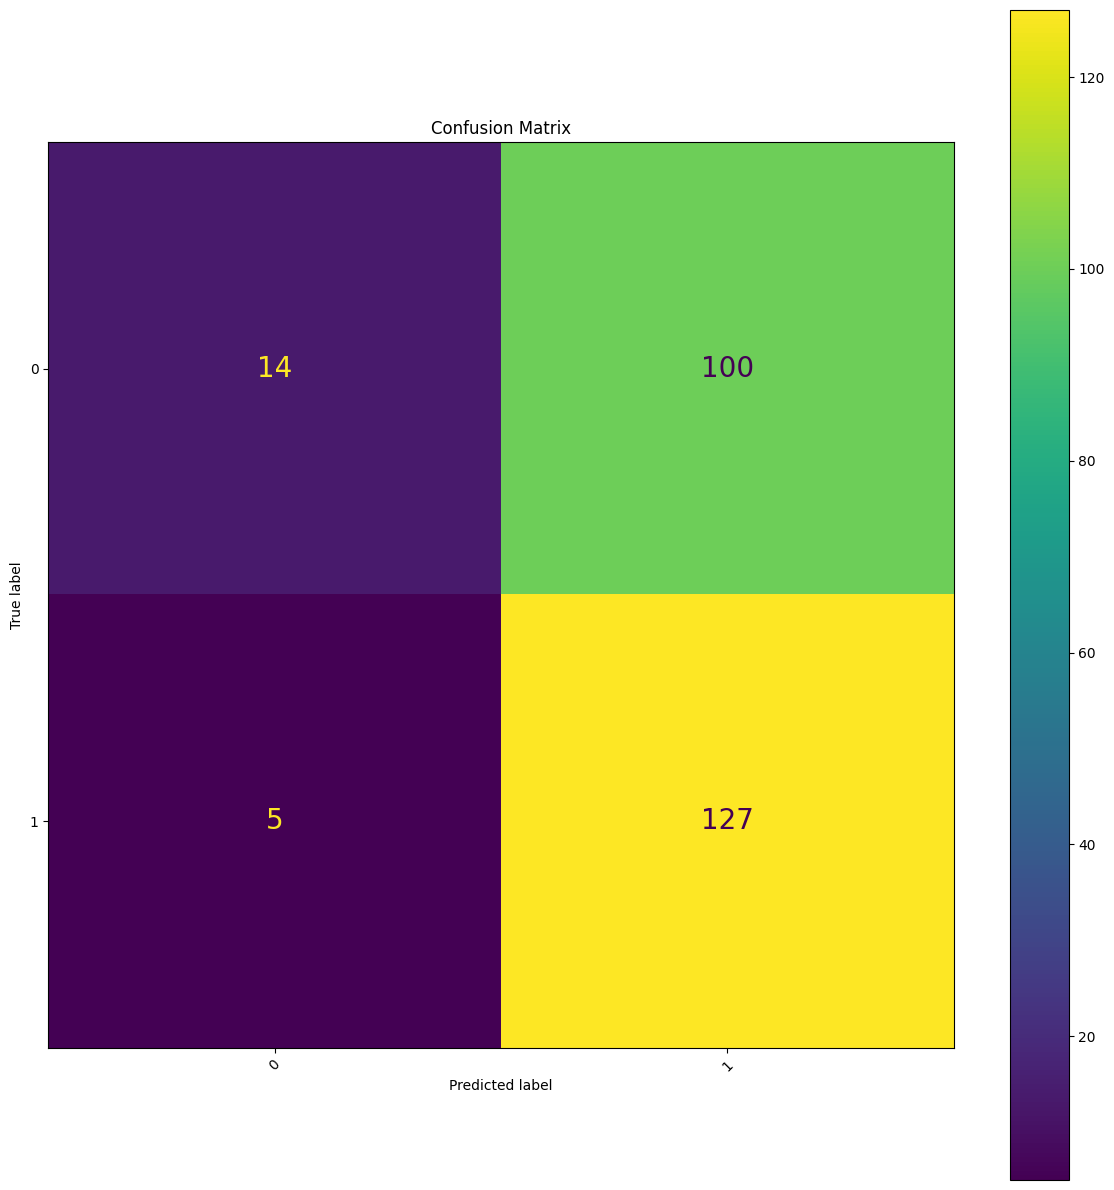

In [67]:
# Define the hyperparameter grid to search

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(eval_metric='logloss'))
])

param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, pos_label=1)   # or pos_label=1 if encoded
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=param_grid, 
    cv = cv,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'accuracy',
    return_train_score=True
)

# Fit to training data
cleaned_com_train_df = pd.DataFrame(cleaned_com_train)
grid_search.fit(cleaned_com_train_df, train_y)

# Best model
best_xgb = grid_search.best_estimator_

fit_model(best_xgb, cleaned_com_train, cleaned_com_val)

When tested across the entire validation set at once, accuracy was 57% while the F1 score on the “up” class was 0.71. This is an improvement upon the initial XGBoost model as well as the support vector classifier from last week. This XGBoost model is now the leading model in performance.

# Picking the Best Model

This section will loop through all the models of the past 3 weeks, and compare validation accuracy as well as F1 score. The accuracy will be compiled into a bar chart with error on the y-axis and model name on the x-axis. Finally, the model with the superior validation performance will be used to generate predictions on the test dataset, and performance will be evaludated.

In [68]:
#make sure we have training and validation datasets available on hand
ts_train_X = cleaned_ts_train.drop(columns = ['Stock Price Direction', 'Dates'])
ts_train_y = cleaned_ts_train['Stock Price Direction']
ts_val_X = cleaned_ts_val.drop(columns = ['Stock Price Direction', 'Dates'])
ts_val_y = cleaned_ts_val['Stock Price Direction']

com_train_X = cleaned_com_train.drop(columns = ['Stock Price Direction'])
com_train_y = cleaned_com_train['Stock Price Direction']
com_val_X = cleaned_com_val.drop(columns = ['Stock Price Direction'])
com_val_y = cleaned_com_val['Stock Price Direction']
com_test_X = cleaned_com_test.drop(columns = ['Stock Price Direction'])
com_test_y = cleaned_com_test['Stock Price Direction']

#to store errors for charts later
train_errors = []
val_errors = []
train_f1s = []
val_f1s = []

def get_error(model, train_X, train_y, val_X, val_y):
    '''Returns the errors of a model given training and validation sets'''
    
    # predictions
    train_pred = model.predict(train_X)
    val_pred = model.predict(val_X)

    # errors
    train_error = 1 - accuracy_score(train_y, train_pred)
    val_error = 1 - accuracy_score(val_y, val_pred)

    # Macro F1
    train_f1 = f1_score(train_y, train_pred, average='macro')
    val_f1 = f1_score(val_y, val_pred, average='macro')

    train_errors.append(train_error)
    val_errors.append(val_error)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    return train_errors, val_errors, train_f1s, val_f1s

# Price Logistic Regression: 
get_error(price_lr_tuned, ts_train_X, ts_train_y, ts_val_X, ts_val_y)

#Sentiment Logistic Regression: 
get_error(best_lr_sentiment,X_train_combined, y_train_sentiment, X_val_combined, y_val_sentiment)

#Combined Dataset Logistic Regression
get_error(lr2, com_train_X, com_train_y, com_val_X, com_val_y)

#Price Support Vector Machine
get_error(price_svm_tuned, ts_train_X, ts_train_y, ts_val_X, ts_val_y)

#Sentiment Support Vector Machine
get_error(best_sentiment_svm, X_train_combined, y_train_sentiment, X_val_combined, y_val_sentiment)

#Combined Support Vector Machine
get_error(best_svm, com_train_X, com_train_y, com_val_X, com_val_y)

#Price XGBoost 
get_error(price_xgb_tuned,  ts_train_X, ts_train_y, ts_val_X, ts_val_y)

#Combined XGBoost
get_error(best_xgb, com_train_X, com_train_y, com_val_X, com_val_y)

#Sentiment FINBERT
get_error(best_lr, X_train_finbert_lr, y_train_finbert_lr, X_val_finbert_lr, y_val_finbert_lr)

([0.485620377978636,
  0.47165160230073955,
  0.4678217821782178,
  0.4847986852917009,
  0.47165160230073955,
  0.4521452145214522,
  0.456861133935908,
  0.39191419141914197,
  0.4552177485620378],
 [0.4581673306772909,
  0.4701195219123506,
  0.4878048780487805,
  0.5258964143426295,
  0.4701195219123506,
  0.44715447154471544,
  0.545816733067729,
  0.426829268292683,
  0.4581673306772909],
 [0.43010304540574373,
  0.3456989247311828,
  0.4740255714542665,
  0.5152009873822487,
  0.3456989247311828,
  0.44094999848490457,
  0.5367427976777304,
  0.5225477390060335,
  0.41743567942709414],
 [0.4512044413179459,
  0.3463541666666667,
  0.4576719576719577,
  0.4740284480568961,
  0.3463541666666667,
  0.43592095388976904,
  0.4462730068758957,
  0.4590236035771881,
  0.4594265595445437])

In [ ]:
#create accuracy table 
model_names = [
    "Price Logistic", "Sentiment Logistic", "Combined Logistic", "Price SVM",
    "Sentiment SVM", "Combined SVM", "Price XGBoost", "Combined XGBoost"
    , "Sentiment FINBERT"
]

accuracy_metrics = pd.DataFrame({
    "Model": model_names,
    "Training Misclassification Error": train_errors,
    "Validation Misclassification Error": val_errors,
    "Training F1": train_f1s,
    "Validation F1": val_f1s
})

accuracy_metrics

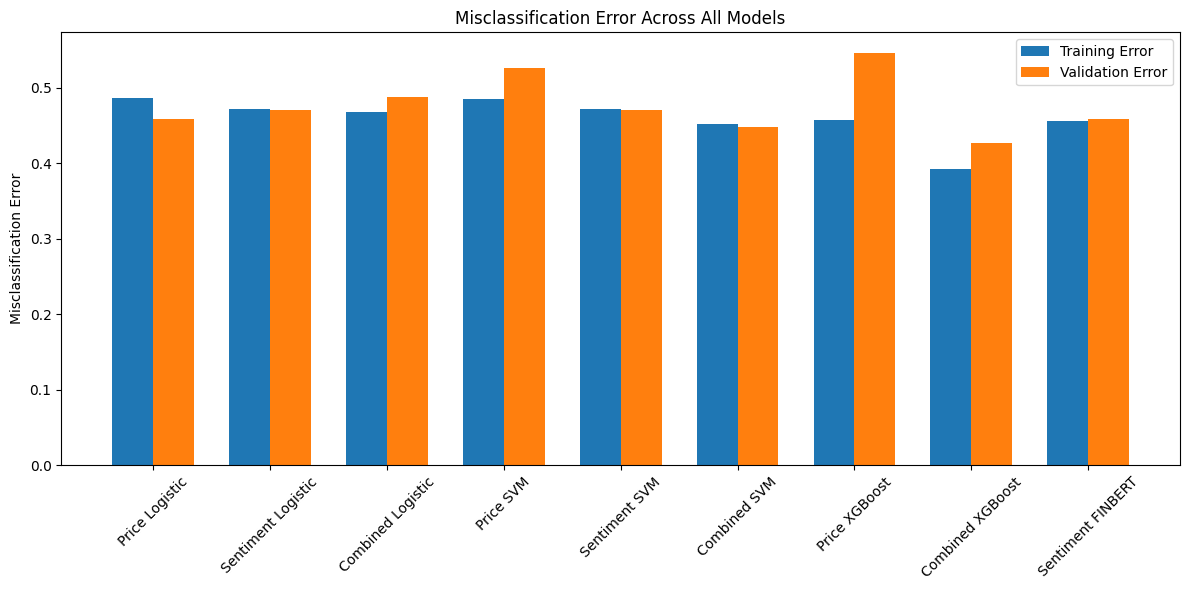

In [69]:
#create chart with error on y-axis, models on x-axis
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_errors, width, label='Training Error')
plt.bar(x + width/2, val_errors, width, label='Validation Error')

plt.xticks(x, model_names, rotation=45)
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error Across All Models")
plt.legend()
plt.tight_layout()
plt.show()


The primary metric used for best model consideration is accuracy with F1 macro average in support. Accuracy is the primary metric because a correct prediction in the increase or decrease of stock price is equally valuable. In the initial assumptions of our product, we assumed that the client made equal profit through investing (associated with an increase in the AAPL stock price) or divesting (associated with a decrease in the AAPL stock price). Therefore, we care most about the percent of correct overall predictions, followed by a metric that balances performance for each stock direction (f1 score). The misclassification error can also be viewed across models in the chart above.

The XGBoost model on the combined dataset had the highest accuracy and lowest misclassification error on the validation dataset. It is not surprising that a model using the combined dataset had the highest accuracy, this model has more information available than any model using the sentiment or historical price datasets. In addition, the XGBoost model is the most complex model of the three using the combined dataset, and the sole model using decision tree methodology, which was improved even further with boosting. This model also likely succeeded because it was able to learn quickly on a small dataset of approximately two thousand observations, where other complex models (like FINBERT) took longer to understand the patterns between features. 

In general, the more complex models tended to have lower errors on the validation datasets. In addition, the models using only historical price tended to perform the worst followed by sentiment data. This is likely due to the complex nature of the dataset needing complex models to understand patterns, and the sentiment and historical price datasets lacking critical information when used individually.

Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                    

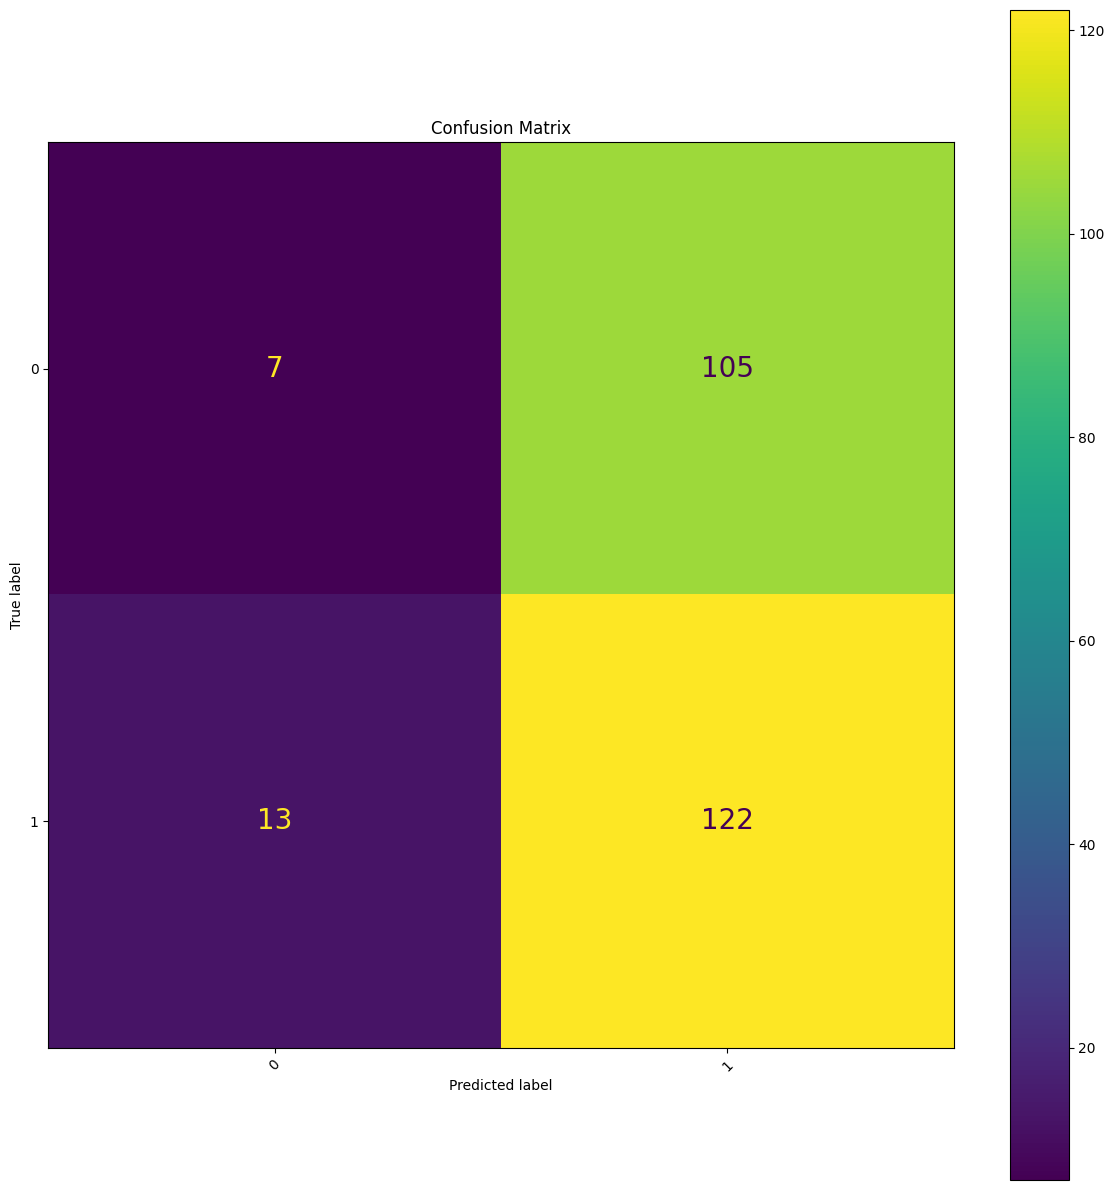

In [70]:
def test_metrics(model, val_X, val_y, print_matrix = True):
    
    #Generate predictions and produce accuracy metrics
    my_pred = model.predict(val_X)
    print(f'Model: {model}')
    print(CR(my_pred, val_y))
    
    #generate confusion matrix
    cm = confusion_matrix(val_y, my_pred, labels=model.classes_)
    
    #print confusion matrix
    if print_matrix:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
        fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size for readability
        disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)
    
        for row in disp.text_:
            for text in row:
                text.set_fontsize(20)
    
    
        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

test_metrics(best_xgb, com_test_X, com_test_y)

This model decreased substantially in accuracy between the training, validation, and test datasets. This shows signals of high variance and is likely due to the model overfitting on the training dataset, which scaled poorly as the datasets changed. 


# Improving Data Quality

In this section, we attempt to improve the data as opposed to the model. We identified three separate techniques to improve data quality. 

Firstly we created lagged versions of the raw AAPL share price, which means it captures the actual numerical value of the stock at previous time steps. Specifically, for each lag from 1 to 5, the .shift(i) function moves the price data down by i rows, so that each new column represents the stock price from prior days. This approach produces continuous-valued features, allowing a model to observe not just whether the price went up or down, but also by how much. As a result, the model can learn patterns related to magnitude, volatility, and trends over time. 

The second step is a technique called SMOTE, which creates synthetic observations for the minority class. This is particularly important for this dataset because the “increase” stock price observations outweighed the “decrease” observations by 53% to 47%. This allowed the model to create a baseline accuracy of 53% simply by predicting all observations as “increase”. SMOTE evens out the discrepancy between the classes, and reduces the possibility of a model optimizing accuracy by predicting a single class. 

We also used the bootstrapping method to see if that would have a positive impact on the model's performance. Bootstrapping is a resampling technique that creates new training datasets by randomly sampling the original dataset with replacement. This means that the same data points can appear multiple times within a sample. Some data points may also not be included at all. 


In [71]:
# Final data cleaning function for the data-centric approach, this will be used to create the X and y datasets for the price, sentiment, and combined models.
# This function will also create lagged variables for the sentiment polarity, which will be used in the models.
def data_centric_cleaning(sentiment_data, ts_data):
    # Create a copy to avoid modifying the original DataFrame
    sentiment_data = sentiment_data.copy()

    # Drop 'Stock Price Direction' from sentiment_data if it exists, since we will be merging with ts_data which has the target variable
    if 'Stock Price Direction' in sentiment_data.columns:
        sentiment_data.drop(columns = 'Stock Price Direction', inplace = True)
    
    #join on date
    df = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'Dates', right_on = 'Dates')

    # Drop 'tokens' column if present (contains lists which are unhashable)
    if 'tokens' in df.columns:
        df = df.drop(columns=['tokens'])

    # Sort by date to ensure correct order for lag creation
    df = df.sort_values('Dates').reset_index(drop=True)

    for i in range(1, 6):
        #create lags for both price and sentiment polarity variables
        df[f'sentiment_polarity_lag{i}'] = df['sentiment_polarity'].shift(i)
        df[f'sentiment_pos_lag{i}'] = df['sentiment_pos'].shift(i)
        df[f'sentiment_neu_lag{i}'] = df['sentiment_neu'].shift(i)
        df[f'sentiment_neg_lag{i}'] = df['sentiment_neg'].shift(i)

    #Create lags for the AAPL Share Price
    for i in range(1, 6):
        df[f'aapl_price_direction_lag{i}'] = df['AAPL Share Price'].shift(i)

    #drop rows that are missing lagged variables
    df.dropna(inplace = True)

    #drop duplicates, but there shouldn't be any because of the primary key date
    df.drop_duplicates(inplace = True)

    #pick the final columns for our dataset
    final_df = df[['Stock Price Direction', 'AAPL Share Price', 'sentiment_polarity', 'sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4', 'aapl_price_direction_lag5']]

    X_data = final_df.drop(columns = ['Stock Price Direction'])
    y_data = final_df['Stock Price Direction']

    return X_data, y_data


In [72]:
X_train_centric, y_train_centric = data_centric_cleaning(Final_Raw_X_train, cleaned_ts_train)

In [73]:
#Apply SMOTE, this weights minority class heavier 
X_train_resampled, y_train_resampled = SMOTE().fit_resample(X_train_centric, y_train_centric)

#Validation creation
X_val_centric, y_val_centric = data_centric_cleaning(Final_Raw_X_val, cleaned_ts_val)

#Test creation
X_test_centric, y_test_centric = data_centric_cleaning(Final_Raw_X_test, cleaned_ts_test)

In [74]:
param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

grid_search = GridSearchCV(XGBClassifier(random_state=42), param_grid, scoring='accuracy', cv=3, n_jobs=1)
grid_search.fit(X_train_resampled, y_train_resampled)
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Best Parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}


In [75]:
# XGBoost for Combined Dataset with bootstrapping
bootstrap_models = []

for i in range(100):
    X_boot, y_boot = resample(X_train_resampled, y_train_resampled, replace=True, random_state=i)
    xgb_boot = XGBClassifier(**best_params,random_state=42)
    xgb_boot.fit(X_boot, y_boot)
    bootstrap_models.append(xgb_boot)

# Aggregate predictions on validation set
val_probas  = np.array([m.predict_proba(X_val_centric)[:, 1]  for m in bootstrap_models]).mean(axis=0)

val_preds  = (val_probas  >= 0.5).astype(int)

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.89      0.64      0.74       159
           1       0.56      0.85      0.68        87

    accuracy                           0.71       246
   macro avg       0.72      0.74      0.71       246
weighted avg       0.77      0.71      0.72       246



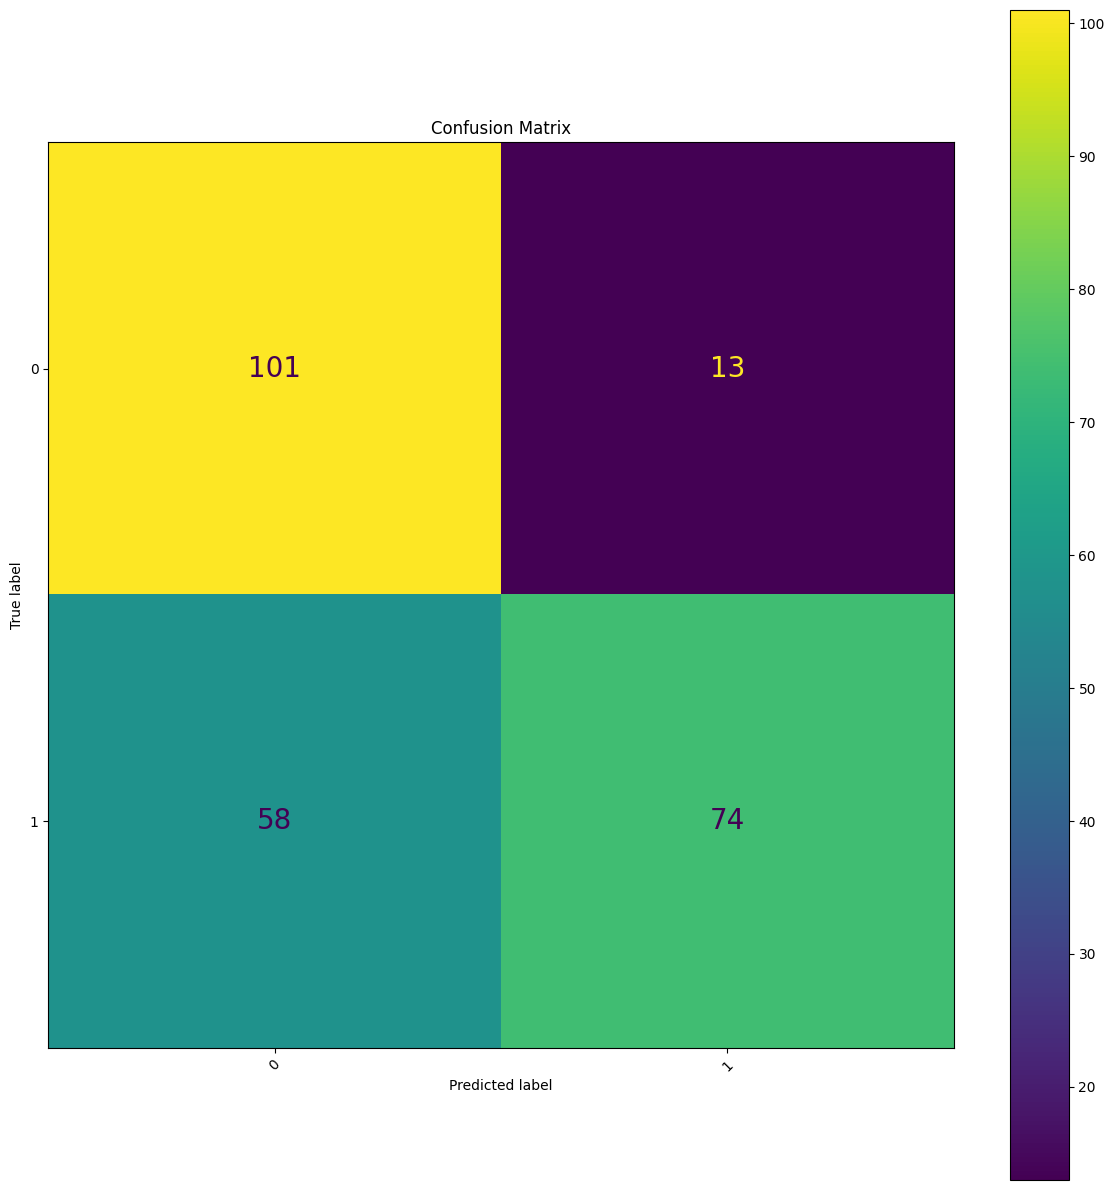

In [76]:
# Validation evaluation
print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(val_preds, y_val_centric))

cm = confusion_matrix(y_val_centric, val_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.93      0.48      0.63       217
           1       0.16      0.73      0.27        30

    accuracy                           0.51       247
   macro avg       0.55      0.61      0.45       247
weighted avg       0.84      0.51      0.59       247



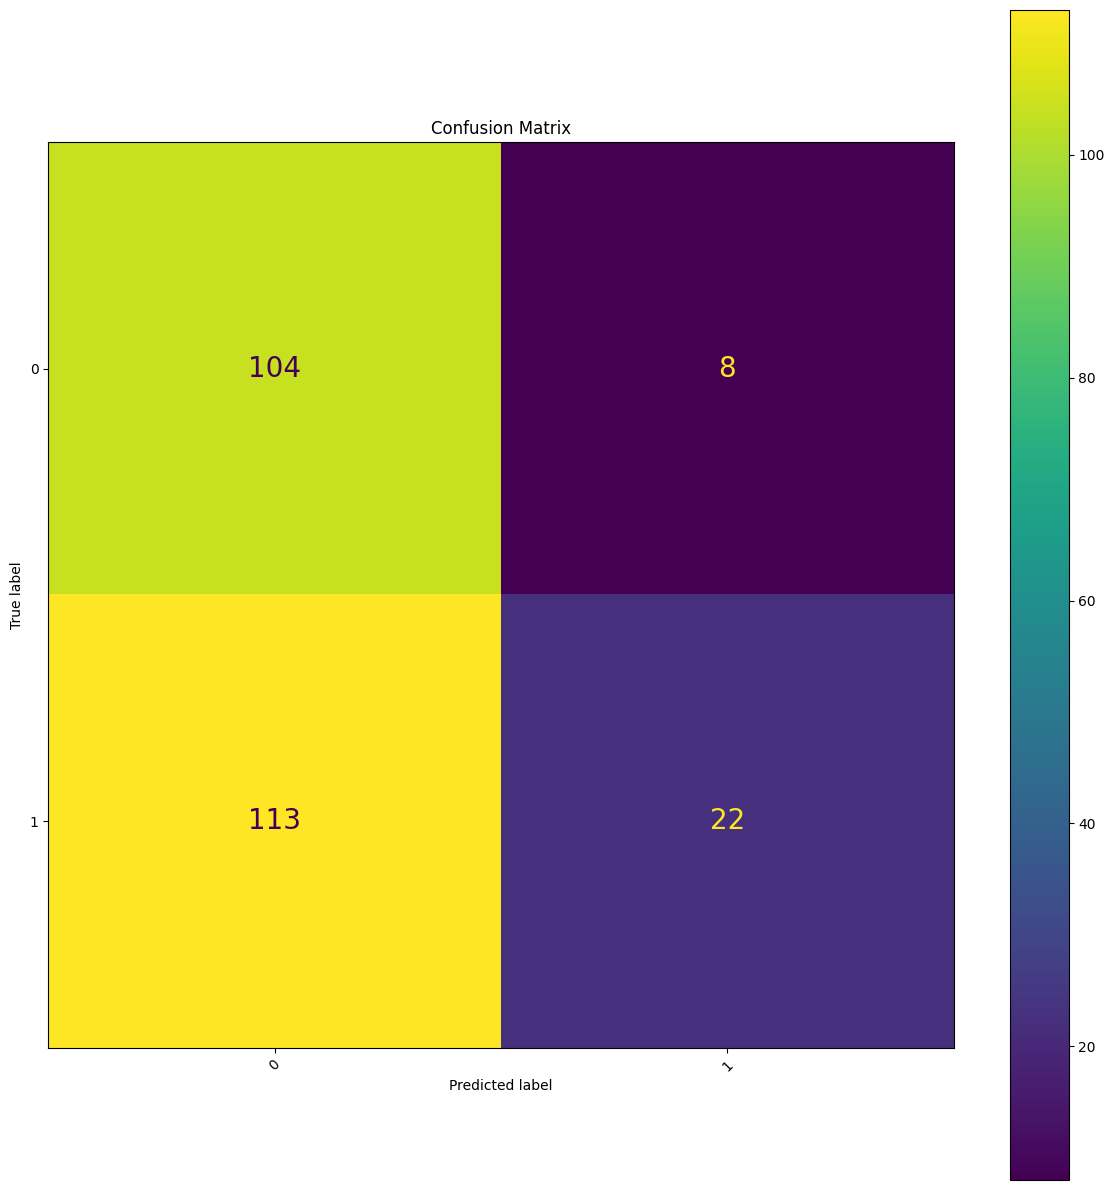

In [77]:
# Test evaluation
test_probas = np.array([m.predict_proba(X_test_centric)[:, 1] for m in bootstrap_models]).mean(axis=0)
test_preds  = (test_probas >= 0.5).astype(int)

print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(test_preds, y_test_centric))

cm = confusion_matrix(y_test_centric, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

With all three techniques implemented, the validation accuracy increased to a promising 71%. This is much higher than the 57% validation accuracy achieved with the previous model. The macro average for the Week 10 model is also much higher than the Week 9 model. This is likely due to the increase of sample size (SMOTE and bootstrapping both helped with this) compared to the previous training dataset, which was severely lacking observation count. The conversion of historical price lags to quantitative variables also provided the model with additional information, which helped inform more accurate predictions. Due to increases in both performance metrics on the validation set, the Week 10 model will be deployed. 

When evaluated on the test dataset, accuracy was slighty lower than the previous week’s model at 51%. This suggests the model is still heavily overfitting on the training and validation datasets, and is unable to extend similar performance to the test dataset.

Our secondary performance metric, the macro average F1 score, did increase from 0.39 to 0.45 in week 10 after the implemented data techniques. The performance across the two classes was much more evenly distributed, with the lowest class f1 score increasing from 0.11 to 0.27. Interestingly, the model implemented this week did a much better job implementing the “decrease” class over the “increase” class, a change from previous weeks’ models. This suggests the SMOTE technique did indeed work, but it now caused the model to be slightly too cautious in predicting increases in stock price direction. 


## Feature Importance

The first part of this assigment will identify the most important features in the model, and then explain how the model generated those features.

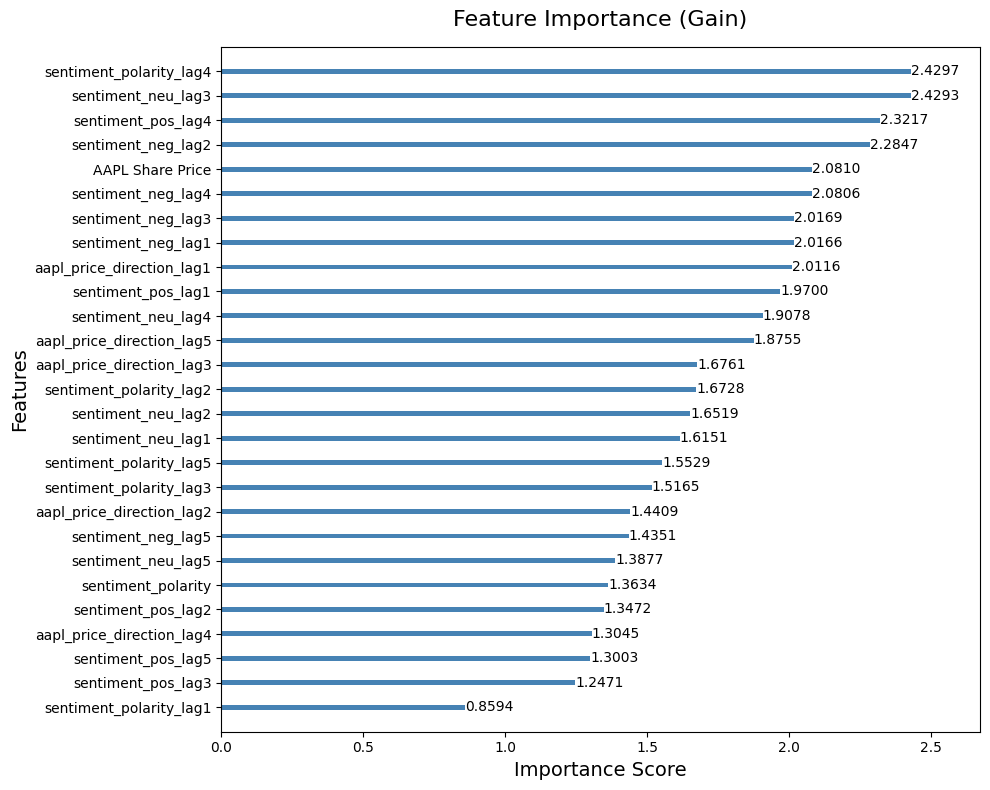

In [78]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plot_importance(
    xgb_boot,
    importance_type='gain',
    ax=ax,
    color='steelblue',
    grid=False,
)

for txt in ax.texts:
    txt.remove()

for container in ax.containers:
    # Only modify bars (not legends)
    if hasattr(container, "datavalues"):
        for bar, value in zip(container, container.datavalues):
            ax.text(
                bar.get_width() + 0.0001,   # slight offset to the right
                bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}",             # round to 4 decimals
                va='center',
                fontsize=10
            )

ax.set_title("Feature Importance (Gain)", fontsize=16, pad=15)
ax.set_xlabel("Importance Score", fontsize=14)
ax.set_ylabel("Features", fontsize=14)

plt.tight_layout()
plt.show()


Overall, this is very interesting because the news sentiment scores ranked much higher than the historical price direction lags. This is perhaps not too surprising since the models trained on solely news sentiment data performed much better than the models trained solely on the historical price data in terms of accuracy and F1 scores. Of the historical price lags, the most recent direction lag was ranked highest, showing that recent price data is still most effective in predicting next-day price direction.

Within the sentiment data, the 2 and 3 day lags between the negative, neutral, and polarity scores were all ranked high in importance. This information suggests that it takes a couple days for news articles to impact stock price direction, and articles containing an extreme amount of negative language as well as extreme overall sentiment (measured through polarity) are correlated with a consumer’s decision to buy or sell stock. Noticeably absent is the percentage of positive language, this ranked very low in feature importance.


## Accounting for Bias 

This week we are focusing on a potential source of bias in the news sentiment dataset. The Apple stock price is reported on in the news individually, but also in context of its competitors. It is reported on in the context of other technology giants, and as a result, their stock price name is occassionally lumped in with other companies despite not being mentioned in the article. Here is an example below:

"S&P 500 ends at new record on stellar tech earnings, surge in U.S. economic growth recorded modest gains on Thursday after a round of upbeat earnings. reports from tech heavyweights, but saw some turbulence midday as Treasury yields rose and investors questioned how much good news was priced into the market."

As a result, the AAPL stock price news is biased by their competitors. If their competitors are doing well, sentiment will rise, and vice versa. We want to eliminate this bias by explicitly filtering to news articles which explicitly mention the Apple stock. This requires a complete re-processing of the sentiment dataset and a re-join on the historical stock price dataset. This, along with model training and evaluation, can all be found below as a part of the extra credit assignment.

In [79]:
def preprocessing_helper(df):
    '''Function for basic NLP preprocessing'''

    #Combine title and content into a single text column for NLP processing and consistency across train, val, and test sets. 
    df['full_text'] = df['title'] + ' ' + df['content']

    # Remove unnecessary columns from data set to focus on text and sentiment features.
    df = df.drop(columns=['title', 'content'])
    
     # Combine all text for the day
    df = df.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
    })
    
    # lowercase the text for consistency
    df['full_text'] = df['full_text'].str.lower()

    # Remove punctuation and special characters from the text
    df['full_text'] = df['full_text'].str.replace(r'[^\w\s]', '', regex=True)

    # Remove extra whitespace
    df['full_text'] = df['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Remove stop words (common words that may not add much meaning to the text)
    df['full_text'] = df['full_text'].apply(
        lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
    )

    #For Nan values in the full_text column, fill with an empty string to allow for NLP processing without errors.
    df['full_text'] = df['full_text'].fillna('')

    #this is the important step. Remove articles that don't have the Apple stock price tag
    df['Apple Mention'] = df['full_text'].apply(lambda x: ('apple' in x.lower()) | ('aapl' in x.lower()))
    df = df.loc[df['Apple Mention'] == True,:]
    df.drop(columns = 'Apple Mention', inplace = True)

    # For Nan values in the sentiment columns, forwardfill up to 7 days ahead and replace remaining NaNs with 0.
    for col in ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_polarity']:
        df[col] = df[col].ffill(limit=7).fillna(0)

    df.index.name = 'Dates'

    return df
    
def bias_removal():
    '''A bias-removal function that removes articles that aren't about AAPL stock price directly'''

    #need to read the raw data again
    raw_data = sentiment_data_creation()

    #sort by dates
    raw_data = raw_data.sort_values('date', ascending=True).reset_index(drop=True)

    #we don't need this columns anymore
    raw_data = raw_data.drop(columns=['link', 'tags'])

    # force sentiment scores to be a numerical value, NA if not 
    for col in ['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity']:
        raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

    # extract valid calendar dates only (ignore time + BST noise)
    raw_data['date'] = pd.to_datetime(
        raw_data['date'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
        errors='coerce'
    ) #This section of the code was inputed to handle warnings from pandas that could lead to future breakage of the code.
    
    # convert content to string, date to a datetime variable
    raw_data['content'] = raw_data['content'].astype('str')
    raw_data['date'] = pd.to_datetime(raw_data['date'])

    #this data is messy, drop observations that have NAs in critical columns
    raw_data = raw_data.dropna(subset=['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity','content','date'])

    # Dropping rows before January 1, 2018 and after October 31, 2024
    raw_data = raw_data[(raw_data['date'] >= '2018-01-01') & (raw_data['date'] <= '2024-10-31')]

    #sort by date
    raw_data = raw_data.sort_values("date").reset_index(drop=True)

    #recreate training, validation, and test datasets
    raw_train = raw_data[(raw_data["date"] >= "2018-01-01") & (raw_data["date"] <= "2022-10-31")]
    raw_val   = raw_data[(raw_data["date"] >= "2022-11-01") & (raw_data["date"] <= "2023-10-31")]
    raw_test  = raw_data[(raw_data["date"] >= "2023-11-01") & (raw_data["date"] <= "2024-10-31")]

    #Call preprocessing function for training, validation, test datasets
    sentiment_train = preprocessing_helper(raw_train)
    sentiment_val = preprocessing_helper(raw_val)
    sentiment_test = preprocessing_helper(raw_test)

    return sentiment_train, sentiment_val, sentiment_test

nb_train, nb_val, nb_test = bias_removal()

In [80]:
def no_bias_cleaning(sentiment_data, ts_data):
    # Create a copy to avoid modifying the original DataFrame
    sentiment_data = sentiment_data.copy()

    # Drop 'Stock Price Direction' from sentiment_data if it exists, since we will be merging with ts_data which has the target variable
    if 'Stock Price Direction' in sentiment_data.columns:
        sentiment_data.drop(columns = 'Stock Price Direction', inplace = True)
    
    #join on date
    df = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'Dates', right_on = 'Dates')

    # Drop 'tokens' column if present (contains lists which are unhashable)
    if 'tokens' in df.columns:
        df = df.drop(columns=['tokens'])

    # Sort by date to ensure correct order for lag creation
    df = df.sort_values('Dates').reset_index(drop=True)

    for i in range(1, 6):
        #create lags for both price and sentiment polarity variables
        df[f'sentiment_polarity_lag{i}'] = df['sentiment_polarity'].shift(i)
        df[f'sentiment_pos_lag{i}'] = df['sentiment_pos'].shift(i)
        df[f'sentiment_neu_lag{i}'] = df['sentiment_neu'].shift(i)
        df[f'sentiment_neg_lag{i}'] = df['sentiment_neg'].shift(i)

    #drop rows that are missing lagged variables
    df.dropna(inplace = True)

    #drop duplicates, but there shouldn't be any because of the primary key date
    df.drop_duplicates(inplace = True)

    #pick the final columns for our dataset
    final_df = df[['Stock Price Direction', 'sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4']]

    X_data = final_df.drop(columns = ['Stock Price Direction'])
    y_data = final_df['Stock Price Direction']

    return X_data, y_data

In [81]:
X_train_nb, y_train_nb = no_bias_cleaning(nb_train, cleaned_ts_train)

#Apply SMOTE, this weights minority class heavier 
X_train_resampled_nb, y_train_resampled_nb = SMOTE().fit_resample(X_train_nb, y_train_nb)

#Validation creation
X_val_nb, y_val_nb = no_bias_cleaning(nb_val, cleaned_ts_val)

#Test creation
X_test_nb, y_test_nb = no_bias_cleaning(nb_test, cleaned_ts_test)

In [82]:
param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

grid_search = GridSearchCV(XGBClassifier(random_state=42), param_grid, scoring='accuracy', cv=5, n_jobs=1)
grid_search.fit(X_train_resampled_nb, y_train_resampled_nb)
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Best Parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}


In [83]:
# XGBoost for Combined Dataset with bootstrapping
bootstrap_models = []

for i in range(100):
    X_boot, y_boot = resample(X_train_resampled_nb, y_train_resampled_nb, replace=True, random_state=i)
    xgb_boot = XGBClassifier(**best_params,random_state=42)
    xgb_boot.fit(X_boot, y_boot)
    bootstrap_models.append(xgb_boot)

# Aggregate predictions on validation set
val_probas  = np.array([m.predict_proba(X_val_nb)[:, 1]  for m in bootstrap_models]).mean(axis=0)

val_preds  = (val_probas  >= 0.5).astype(int)

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.62      0.53      0.57       134
           1       0.52      0.62      0.57       112

    accuracy                           0.57       246
   macro avg       0.57      0.57      0.57       246
weighted avg       0.58      0.57      0.57       246



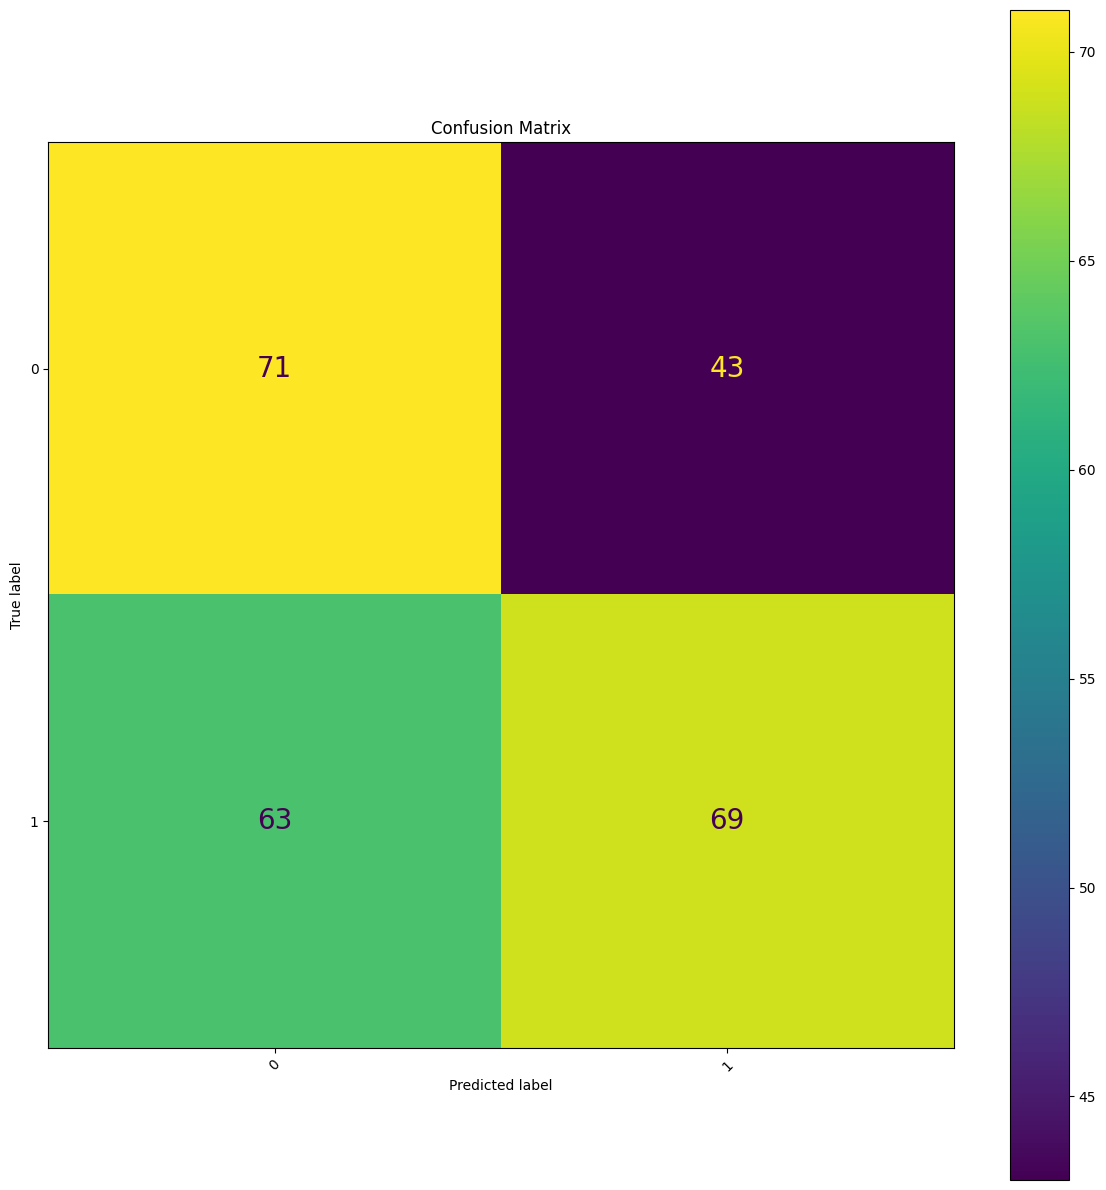

In [84]:
# Validation evaluation
print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(val_preds, y_val_nb))

cm = confusion_matrix(y_val_nb, val_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.63      0.50      0.56       137
           1       0.49      0.61      0.54       106

    accuracy                           0.55       243
   macro avg       0.56      0.56      0.55       243
weighted avg       0.57      0.55      0.55       243



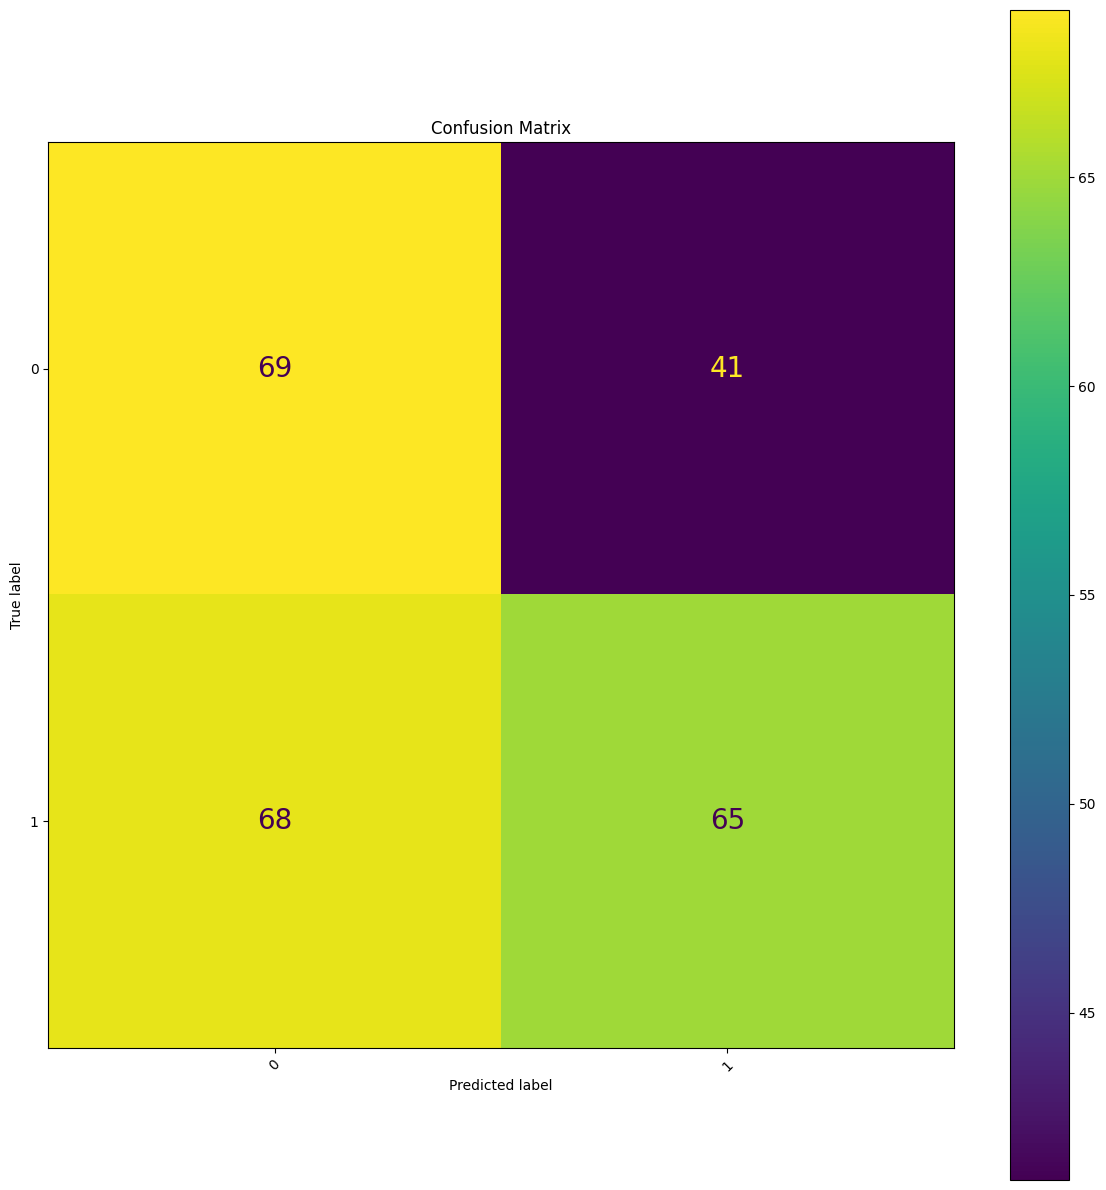

In [85]:
# Test evaluation
test_probas = np.array([m.predict_proba(X_test_nb)[:, 1] for m in bootstrap_models]).mean(axis=0)
test_preds  = (test_probas >= 0.5).astype(int)

print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(test_preds, y_test_nb))

cm = confusion_matrix(y_test_nb, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

This week’s model with reduced bias actually surpassed Week 10’s model on the test dataset in both accuracy and F1 score, despite achieving lower performance on the validation set. This suggests that the bias removal helped with overfitting, which was a large problem in previous weeks, and removed some of the “noise” that previously caused this model to train on false patterns in the data. In addition, the F1 scores for the “increase” and “decrease” classes were only separated by 0.02, a balance no prior model had been able to achieve. 

## Saving Model

In [86]:
# Save your trained model or pipeline
joblib.dump(xgb_boot,"stock_direction_model.pkl")

['stock_direction_model.pkl']

## References

Ismail Olaniyi Muraina. “IDEAL DATASET SPLITTING RATIOS in MACHINE LEARNING ALGORITHMS: GENERAL CONCERNS for DATA SCIENTISTS AND...” ResearchGate, unknown, 3 Feb. 2022, www.researchgate.net/publication/358284895_IDEAL_DATASET_SPLITTING_RATIOS_IN_MACHINE_LEARNING_ALGORITHMS_GENERAL_CONCERNS_FOR_DATA_SCIENTISTS_AND_DATA_ANALYSTS. Accessed 6 Feb. 2026.
